In [1]:
import os
from scipy.io import loadmat
import numpy as np
# Ruta del archivo que se quiera cargar
home_dir = os.path.expanduser("~")
DataSimCianos = os.path.join(home_dir, "Desktop", "Spline Optimizer", "Saves", "simulationSol-E9.mat")

# Cargar el archivo MAT
data = loadmat(DataSimCianos)  # Aquí cargamos el archivo realmente

# Mostrar las claves (variables almacenadas en el archivo)
#print(data.keys())

# Acceder a una tabla específica por su clave (reemplaza 'nombre_tabla' por la clave real)
IDLogs = data["IDLog"] #Dimensiones: [instantes de tiempo x nº máx de partículas en algún instante] ej: [187x612]
#print("Tabla IDLogs: \n", IDLogs) 
parentCell = data["parentCell"] #Dimensiones: [1 x nº total de partículas que aparecen en la simulación] ej: [1x1261]
#print("Tabla parentCell: \n", parentCell)
tVec = data["tVec"] #Dimensiones [1 x instantes de tiempo] ej: [1x187]
#tVec está en dias, lo pasamos a minutos
tVec_min = tVec*24*60
#print("Tabla tVec", tVec)
xCellLog = data["xCellLog"] #Dimensiones [instantes de tiempo x nº máximo de partículas en algún instante x (x, y, z)] ej: [187x612x3]
#print("Tabla xCellLog: \n", xCellLog)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      500 |      8 |             - |             -
     2 |     1000 |      6 |  0.5775996968 |         nadir
     3 |     1500 |      3 |  0.4166666667 |         ideal
     4 |     2000 |      7 |  0.0406766824 |         ideal
     5 |     2500 |      6 |  0.0666666667 |         ideal
     6 |     3000 |      7 |  0.0103377093 |         nadir
     7 |     3500 |      3 |  0.2500000000 |         ideal
     8 |     4000 |      6 |  0.3717438681 |         ideal
     9 |     4500 |      4 |  0.3983223118 |         ideal
    10 |     5000 |      5 |  0.0538829945 |         ideal
    11 |     5500 |      4 |  0.9090909091 |         ideal
    12 |     6000 |      5 |  0.1231768639 |             f
    13 |     6500 |      7 |  0.0500000000 |         ideal
    14 |     7000 |      4 |  0.0476190476 |         ideal
    15 |     7500 |      3 |  0.2173913043 |         ideal
    16 |     8000 |      2 |  3.3897298453 |         ide

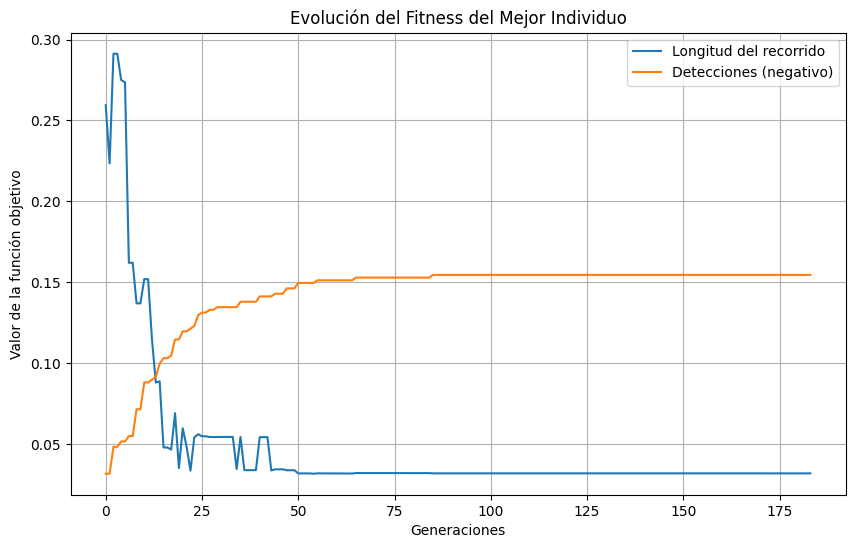

500


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from pymoo.core.mutation import Mutation
from pymoo.core.crossover import Crossover
from pymoo.core.sampling import Sampling
from pymoo.core.population import Population
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.algorithms.moo.nsga2 import binary_tournament
from pymoo.operators.survival.rank_and_crowding.metrics import calc_crowding_distance
from pymoo.core.problem import ElementwiseProblem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.algorithms.soo.nonconvex.brkga import EliteSurvival

from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling

from pymoo.operators.survival.rank_and_crowding import RankAndCrowding
from pymoo.util.randomized_argsort import randomized_argsort
from pymoo.core.survival import Survival

from pymoo.termination.default import DefaultMultiObjectiveTermination


# === Muestreo personalizado ===

class CustomSampling(Sampling):
    def __init__(self, punto_ini, punto_fin):
        super().__init__()
        self.punto_ini = punto_ini
        self.punto_fin = punto_fin
        
    def _do(self, problem, n_samples, **kwargs):
        samples = np.zeros((n_samples, problem.n_var))  # Matriz de muestras [Población x Variables]
        #print(f"xl = {problema.xl} \n xu = {problema.xu}")
        for i in range(n_samples):
            sample = []
            sample.extend(self.punto_ini)
            #print(self.punto_ini)
            for j in range(3, problem.n_var-3, 3):  # Iterar en pasos de 3 (x, y, z)
                while True:  # Repetir hasta que la distancia mínima se cumpla
                    x = np.random.uniform(problem.xl[j], problem.xu[j])   # Generar X dentro del rango
                    y = np.random.uniform(problem.xl[j+1], problem.xu[j+1]) # Generar Y dentro del rango
                    z = np.random.uniform(problem.xl[j+2], problem.xu[j+2]) # Generar Z dentro del rango
                    nueva_pos = [x, y, z]
                    #print(f"nueva_pos = {nueva_pos}")
                    # Comprobar la distancia mínima entre la nueva partícula y las anteriores
                    dist_violada = False
                    for k in range(0, len(sample), 3):  # Revisar distancias con las partículas previas
                        if calcular_distancia(nueva_pos, sample[k:k+3]) <= problem.rango_deteccion:
                            dist_violada = True
                            break
                    
                    # Si no se viola la condición de distancia mínima, se agrega
                    if not dist_violada:
                        sample.extend(nueva_pos)
                        break
            sample.extend(self.punto_fin)
            samples[i] = sample  # Guardar el individuo generado
            #np.savetxt("sample.txt", samples)
        return samples

# === Cruce personalizado ===

class CustomCrossover(Crossover):
    def __init__(self, crossover_prob=0.5):
        super().__init__(2, 2)  # 2 padres -> 2 hijos
        self.crossover_prob = crossover_prob  # Probabilidad de cruce
        
    def _do(self, problem, X, **kwargs):
        _, n_matings, n_var = X.shape  # Dimensiones de los padres
        Y = np.full_like(X, np.nan)
        n_elite = 0
        n_no_elite = 0
        n_cruce = 0
        #print(f"Cruce a {X.shape}")
        #print(f"Población elite en el cruce {elite}")
        num_points = n_var // 3
        for i in range(n_matings):
            parent1, parent2 = X[0, i].copy(), X[1, i].copy()  
            # parent1 = parent1 + np.random.rand()
            # parent2 = parent2 + np.random.rand()
            # Verificar si los padres están en élite
            if any(np.array_equal(parent1, e) for e in elite) or any(np.array_equal(parent2, e) for e in elite):
                
                # Si alguno de los padres está en élite, pasa sin cambios
                if any(np.array_equal(parent1, e) for e in elite):
                    
                    #pasamos el padre 1 sin cruzar porque está en la élite
                    Y[0, i] = parent1

                    #Cruzamos el padre 1 (de la elite) con el padre 2 (no en la elite) para obtener el hijo2
                    child2 = np.copy(parent2)
                    
                    start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                    start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)
    
                    # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                    max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                    if max_blocks > 0:
                        # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                        num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                        length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                        
                        # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                        child2[start:start+length] = parent1[start:start+length]
                    else:
                        # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                        child2 = parent2.copy()
        
                    # Asignar los hijos generados a la población de hijos
                    Y[1, i] = child2
                    
                if any(np.array_equal(parent2, e) for e in elite):
                    #pasamos el padre 1 sin cruzar porque está en la élite
                    Y[1, i] = parent2

                    #Cruzamos el padre 1 (de la elite) con el padre 2 (no en la elite) para obtener el hijo2
                    child1= np.copy(parent1)
                    
                    start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                    start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)
    
                    # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                    max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                    if max_blocks > 0:
                        # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                        num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                        length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                        
                        # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                        child1[start:start+length] = parent2[start:start+length]
                    else:
                        # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                        child1 = parent1.copy()
        
                    # Asignar los hijos generados a la población de hijos
                    Y[0, i] = child1
            
            else:
                n_no_elite +=1
                # Aplicar cruce con probabilidad crossover_prob
                if np.random.rand() < self.crossover_prob:
                    n_cruce +=1
                    # Si se cruza, generar los hijos
                    child1, child2 = np.copy(parent1), np.copy(parent2)
    
                    # Limitar el punto de inicio del cruce para que no afecte la primera coordenada
                    # start debe ser un múltiplo de 3 (porque cada punto tiene 3 variables)
                    start_point = np.random.randint(1, num_points - 1)  # Aseguramos que no sea ni el primer ni el último punto
                    start = start_point * 3  # Convertimos a índice de coordenadas (multiplicamos por 3)
    
                    # Determinar cuántos bloques consecutivos de coordenadas se van a intercambiar
                    max_blocks = (n_var - start - 3) // 3  # Máximo número de bloques que caben
                    if max_blocks > 0:
                        # El número de bloques a intercambiar (al menos 1 y como máximo max_blocks)
                        num_blocks = np.random.randint(1, max_blocks + 1)  # El número de bloques a intercambiar
                        length = num_blocks * 3  # Cada bloque contiene 3 elementos (x, y, z)
                        
                        # Intercambiar el segmento seleccionado entre los padres (bloques de 3)
                        child1[start:start+length] = parent2[start:start+length]
                        child2[start:start+length] = parent1[start:start+length]
                    else:
                        # Si no hay bloques disponibles para intercambiar, los hijos son iguales a los padres
                        child1, child2 = parent1.copy(), parent2.copy()
        
                    # Asignar los hijos generados a la población de hijos
                    Y[0, i] = child1
                    Y[1, i] = child2
                else:
                    # Si no se cruza, los hijos son idénticos a los padres
                    Y[0, i] = parent1
                    Y[1, i] = parent2

        # with open("crossover_output.txt", "w") as f:
        #     f.write("Padre 1".ljust(15) + "Padre 2".ljust(15) + "Hijo 1".ljust(15) + "Hijo 2".ljust(15) + "\n")
        #     f.write("=" * 60 + "\n")
        
        #     for i in range(n_matings):
        #         for j in range(n_var):
        #             f.write(f"{X[0, i, j]:<14.4f} {X[1, i, j]:<14.4f} {Y[0, i, j]:<14.4f} {Y[1, i, j]:<14.4f} \n")
        #         f.write("-" * 60 + "\n")

        
        return Y  # ¡IMPORTANTE! Siempre devolver Y

# === Mutación personalizada ===

class CustomMutation(Mutation):
    def __init__(self, prob=0.2, heavy_prob=0.015, lower=None, upper=None):
        super().__init__()
        self.prob = prob
        self.heavy_prob = heavy_prob
        self.lower = lower
        self.upper = upper
    def _do(self, problem, X, **kwargs):
        n_ind, n_var = X.shape  
        mutated_X = np.copy(X)
        n_mutations = 0
        #print("Mutación")
        #print(f"Mutación a {len(X)}")
        #print(f"Población elite en la mutacion {elite}")
        #print(f"Lower = {self.lower} \n Upper = {self.upper}")
        for i in range(n_ind):
            n_mutations +=1
            if any(np.array_equal(mutated_X[i], e) for e in elite):
                #print("ELITE EN MUTACION")
                continue  # Si el individuo está en élite, no se muta
            if np.random.rand() > self.prob:
                continue #Si el número generado es mayor que la probabilidad de mutación, ese individuo no muta
            # Aplicamos mutación con probabilidad `self.prob`
            mask = np.random.rand(n_ind, n_var) < self.prob #Se crea una máscara para que, en caso de que ese individuo mute, luego cada gen tenga una probabilidad de mutación
            mask_heavy_mutation = np.random.rand(n_ind, n_var) < self.heavy_prob
            mask[:, :3] = False
            mask[:, -3:] = False
            mask_heavy_mutation[:, :3] = False
            mask_heavy_mutation[:, -3:] = False
            mask_combined = mask | mask_heavy_mutation
            noise = np.random.randn(n_ind, n_var) * problema.rango_deteccion  # Ruido gaussiano
            heavy_noise = np.random.randn(n_ind, n_var) * problem.rango_deteccion * 100
            final_noise = np.zeros((n_ind, n_var))
            final_noise[mask] = noise[mask]
            final_noise[mask_heavy_mutation] = heavy_noise[mask_heavy_mutation]
            mutated_X[mask_combined] += final_noise[mask_combined]

        # with open("mutacion_output.txt", "w") as f:
        #     f.write("Individuo | Variable | Mascara | Mascara heavy | Original | Mutado | Noise \n")
        #     f.write("-" * 90 + "\n")

        #     for w in range(n_ind):
        #         for j in range(n_var):
        #             f.write(f"{w+1:<9} | {j+1:<8} | {int(mask[w,j]):<7} | {int(mask_heavy_mutation[w,j]):<13} | {X[w, j]:<10.4f} | {mutated_X[w, j]:<10.4f} | {final_noise[w,j]:<8.4f}\n")
        #         f.write("\n")  # Separación entre individuos
        #print(f"N_mutations = {n_mutations}\n Poblacion mutada = {mutated_X.shape}")
        return mutated_X



# === Función para calcular la distancia Euclidiana en 3D === #

def calcular_distancia(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2+(p1[1]-p2[1])**2)
    
# # === Función para eliminar partículas dentro del rango de detección ===

def eliminar_particulas_en_rango(mapa, centro, rango_deteccion, indices_detectados, indices_eliminadas):
    # Convertir centro en array numpy
    centro = np.array(centro[:2])
    # Filtrar partículas que no han sido detectadas y no tienen NaN
    
    mascara_validas = (indices_eliminadas == 0)
    mascara_detectadas = (indices_eliminadas == 1)
    
    #print(f"Centro = {centro}")
    
    # Calcular distancias solo para las partículas válidas
    distancias = np.linalg.norm(mapa[mascara_validas, :2] - centro[:2], axis=1)
    distancias_repetidas = np.linalg.norm(mapa[mascara_detectadas, :2] - centro[:2], axis=1)
    #mascara_pasadas_previamente = (indices_detectados[0:len(distancias)] == 1) & (distancias <= rango_deteccion)
    
    # Encontrar las partículas dentro del rango de detección
    
    # Marcar las partículas detectadas en indices_detectados
    indices_detectados[mascara_validas] = (distancias <= rango_deteccion).astype(int)
    indices_eliminadas[mascara_validas] = (distancias <= rango_deteccion*3).astype(int)
    # if deteccion != np.sum(indices_detectados):
    #     print(F"NO CUADRAN DETECCIONES \n Detecciones = {deteccion} \n indice = {np.sum(indices_detectados)}")
        
    return indices_detectados, indices_eliminadas

# === Problema de optimización ===
class OptimizacionConDeteccion(ElementwiseProblem):
    def __init__(self, mapa_particulas, n_puntos=10, rango_deteccion=5, max_dist=1000, v_media=1):
        self.mapa_particulas = mapa_particulas  # Partículas en 3D
        self.rango_deteccion = rango_deteccion
        self.n_puntos = n_puntos
        self.max_dist = max_dist
        self.v_media = v_media
        self.xl = np.array([-600, -400, -20])
        self.xu = np.array([600, 200, 0])
        self.mejor_fitness = float('inf')  # Inicializa como un valor muy alto
        self.mejor_deteccion = 0
        self.mapa_dinamico_mejor = None  # Para guardar el mejor mapa dinámico
        self.mejor_individuo = None
        self.long_max = calcular_distancia(self.xl[:2], self.xu[:2]) #Calculamos la longitud máxima para normalizar las longitudes
        # Definir el número de variables como el número de puntos de paso (n_puntos * 3 coordenadas)
        super().__init__(n_var=n_puntos*3, 
                         n_obj=2, 
                         n_constr=0, 
                         xl=np.tile(self.xl, n_puntos), 
                         xu=np.tile(self.xu, n_puntos))

    def _evaluate(self, x, out, *args, **kwargs):
        # x contiene los índices de las partículas ordenadas para el recorrido
        recorrido = [x[i:i+3] for i in range(0, len(x), 3)]

        # Longitud total del recorrido
        longitud_recorrido = 0
        penalty = 0
        mov=0
        longitudes=[]
        detecciones_totales = 0
        #detecciones_totales = [np.zeros(len(self.mapa_particulas[1]))]
        repetidas_totales = 0
        tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
        indices_detectados = np.zeros(len(self.mapa_particulas[1]))
        indices_eliminadas = np.zeros(len(self.mapa_particulas[1]))
        pesos_gaussianos_i =  np.zeros(len(self.mapa_particulas[1]))
        aportaciones = np.zeros(len(self.mapa_particulas[1]))
        indices_repetidas = np.zeros(len(self.mapa_particulas[1])) 
        t_medida_ant = 120/60
        # Iterar sobre el recorrido y calcular la longitud total
        for i in range(len(recorrido)):
            deteccion = 0
            p1 = recorrido[i]
            if (i < len(recorrido)-1):
                p2 = recorrido[i + 1]
                longitud_recorrido += calcular_distancia(p1, p2)

            tAct = tiempo + longitud_recorrido/(self.v_media*60)+t_medida_ant*(i+1) #El i+i es para sumar el tiempo de cada vez que se ha medido
            dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
            indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
            
            #print(f"tAct: {tAct}, tVec: {tVec_min}")
            #print(f"Diferencia absoluta: {dif_tVec_tAct}")
            #print(f"Índice del valor más cercano: {indice_tVec}")
            
            # Actualizar el mapa y contar las partículas detectadas
            indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, self.rango_deteccion, indices_detectados, indices_eliminadas)
             
            
            if (i < len(recorrido)-1):
                mov += calcular_distancia(p1, p2)
                if mov <= self.rango_deteccion or mov > self.max_dist:
                    penalty += 1/self.n_puntos
                else:
                    penalty += 0
                    
        detecciones_totales = np.sum(indices_detectados)
        # Definir la función objetivo: minimizar la longitud y maximizar las detecciones
        out["F"] = [longitud_recorrido/(self.n_puntos*calcular_distancia(problema.xl, problema.xu)), -1.5*detecciones_totales/problema.mapa_particulas.shape[1]]  # Usamos -detecciones_totales para maximizar. Normalizamos las detecciones con el n máx de partículas y la longitud con la longitud máxima de la población
        #out["G"] = [g]

convergence = []
elite = []
def callback(algorithm):
    global elite
    gen = algorithm.n_gen
    pop = algorithm.pop
    F = pop.get("F")  # Obtener valores de función objetivo de la población
    rank = pop.get("rank")
    
    # Obtener el mejor (mínimo) valor de cada función objetivo
    best_fitness_detecc_ind = np.argmin(F[:,1])
    best_fitness = F[best_fitness_detecc_ind] 

    # Guardar el mejor fitness de cada generación
    convergence.append(best_fitness)

    elite_indices =  np.argsort(rank)
    
    elite_individuals = [pop[i] for i in elite_indices[:50]]  # Seleccionamos los 5 mejores
    # Guardar los valores de decisión (variables de diseño) de los individuos élite
    elite = [ind.X.copy() for ind in elite_individuals]
    #print(f"Elite pop = {len(elite)}")
    
# Crear el problema de optimización
problema = OptimizacionConDeteccion(xCellLog)
pop_size = 500



# Crear el algoritmo NSGA-II
algorithm = NSGA2(
    pop_size=pop_size,
    #n_offsprings=10,
    selection=TournamentSelection(func_comp=binary_tournament),
    survival=RankAndCrowding(crowding_func = "pcd"),
    crossover=CustomCrossover(),
    mutation=CustomMutation(lower = problema.xl, upper = problema.xu),
    sampling=CustomSampling(punto_ini =[0, 0, 0], punto_fin = [0, 0, 0]),
    #mutation=PM(prob=0.2, eta=10),
    eliminate_duplicates=True,
    callback = callback
)
algorithm.callback = callback
termination = DefaultMultiObjectiveTermination(
    xtol=1e-7,
    cvtol=1e-6,
    ftol=0.0025,
    period=30,
    n_max_gen=500,
    n_max_evals=1000000
)

# Ejecutar la optimización
result = minimize(
    problema,
    algorithm,
    termination,
    seed=42,
    verbose=True,
    save_history=True,
    callback=callback
)

n_evals = np.array([e.evaluator.n_eval for e in result.history])
opt = np.array([e.opt[0].F for e in result.history])

convergence = np.array(convergence)

# Crear la gráfica
plt.figure(figsize=(10, 6))

plt.plot(convergence[:, 0], label="Longitud del recorrido")
plt.plot(-convergence[:, 1], label="Detecciones (negativo)")

plt.xlabel("Generaciones")
plt.ylabel("Valor de la función objetivo")
plt.title("Evolución del Fitness del Mejor Individuo")
plt.legend()
plt.grid()
plt.show()

print(len(result.F))

Soluciones en el frente pareto = (500,)


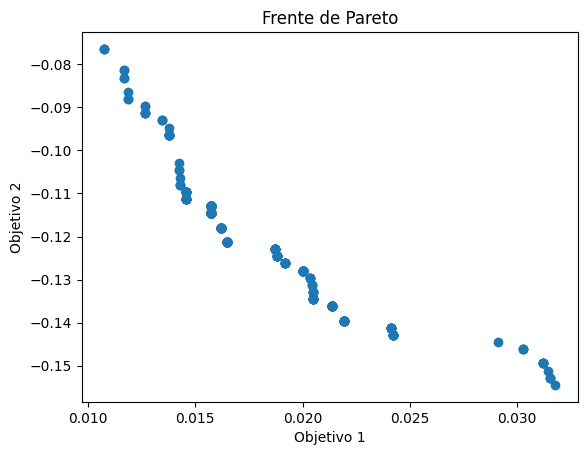

In [31]:
print(f"Soluciones en el frente pareto = {result.F[:, 1].shape}")
plt.scatter(result.F[:, 0], result.F[:, 1])
plt.xlabel("Objetivo 1")
plt.ylabel("Objetivo 2")
plt.title("Frente de Pareto")
plt.show()


## SELECCION DEL INDIVIDUO FINAL DE DIFERENTES FORMAS

SUMA PONDERADA

In [46]:
weights = np.array([0.4, 0.6])  # Ajusta según tus preferencias
scores = (result.F * weights).sum(axis=1)  # Calcula la función agregada
best_idx = np.argmin(scores)  # Minimización
mejor_individuo = result.X[best_idx]

#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]
t_medida = 120/60
tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
indices_eliminadas = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0
tiempos_ruta = np.zeros(int(mejor_individuo/3))

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    print(i)
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0] + t_medida
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60) + t_medida  # v_media en m/min. Aquí se suma t_medida sin multiplicar ya que se van cogiendo tiempos anteriores
        print(f"Distancia recorrida en este tramo = {calcular_distancia(p1, p2)} en {(calcular_distancia(p1, p2) / (v_media * 60))*60} s")
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"indice_tVec = {indice_tVec}")
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tVec_min[0, 0])*60}")
    print(f"Tiempo del tramo (s): {(tiempos_ruta[i]-tiempos_ruta[i-1])*60}")
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, problema.rango_deteccion, indices_detectados, indices_eliminadas)
    mapa_dinamico_detecciones[i] = indices_detectados




for i in range(len(vector_tiempos)):
    print(i)
    deteccion = 0
    p1 = recorrido[i]
    if (i != 0 and i != len(recorrido) - 1):
        p2 = recorrido[i + 1]
        longitud_recorrido += calcular_distancia(p1, p2)
    #print(f"p{i} = {p1}")
    print(f"Longitud total recorrida = {longitud_recorrido}")
    print(f"Longitud recorrida en este tramo = {calcular_distancia(p1, p2)} en {calcular_distancia(p1, p2)/problema.v_media}s")
    tAct = tiempo + longitud_recorrido/(problema.v_media*60) + t_medida*(i+1)
    print(f"Tiempo del recorrido en s= {(tAct - tiempo)*60}")
    print(f"Tiempo en el mapa = {tAct}")
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    print(f"Indice tVec = {indice_tVec}")
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    # Actualizar el mapa y contar las partículas detectadas

detecciones_totales = np.sum(indices_detectados)
print(f"Detecciones totales = {detecciones_totales}")
print(f"Longitud recorrido = {longitud_recorrido}")

0
Longitud total recorrida = 0
Longitud recorrida en este tramo = 0.0 en 0.0s
Tiempo del recorrido en s= 120.0
Tiempo en el mapa = 93602.0
Indice tVec = 0
1
Longitud total recorrida = 22.096473286393746
Longitud recorrida en este tramo = 22.096473286393746 en 22.096473286393746s
Tiempo del recorrido en s= 262.0964732862194
Tiempo en el mapa = 93604.36827455477
Indice tVec = 0
2
Longitud total recorrida = 42.309824196976194
Longitud recorrida en este tramo = 20.21335091058245 en 20.21335091058245s
Tiempo del recorrido en s= 402.30982419656357
Tiempo en el mapa = 93606.70516373661
Indice tVec = 0
3
Longitud total recorrida = 122.67333743488861
Longitud recorrida en este tramo = 80.36351323791241 en 80.36351323791241s
Tiempo del recorrido en s= 602.673337434826
Tiempo en el mapa = 93610.04455562391
Indice tVec = 0
4
Longitud total recorrida = 163.16334938715073
Longitud recorrida en este tramo = 40.490011952262115 en 40.490011952262115s
Tiempo del recorrido en s= 763.1633493871777
Tiempo 

In [49]:
recorrido

[array([0., 0., 0.]),
 array([ 16.69933126, -22.45494165,  -5.78145923]),
 array([ 16.78242957, -44.55125868, -13.30984387]),
 array([-2.19126466e-02, -3.33176645e+01, -8.80218936e+00]),
 array([-61.30593289, -85.30384656, -15.92928955]),
 array([-23.22236603, -71.55310102,  -7.36450313]),
 array([-44.32644827, -59.89522986, -14.93481366]),
 array([ 16.62535705, -94.66566665, -12.6143846 ]),
 array([ 58.61010671, -73.15847113,  -8.69852417]),
 array([0., 0., 0.])]

0
indice_tVec = 0
Tiempo de la ruta (s): 120.0
Tiempo del tramo (s): 5616120.0
INDICES DETECTADOS = 0.0


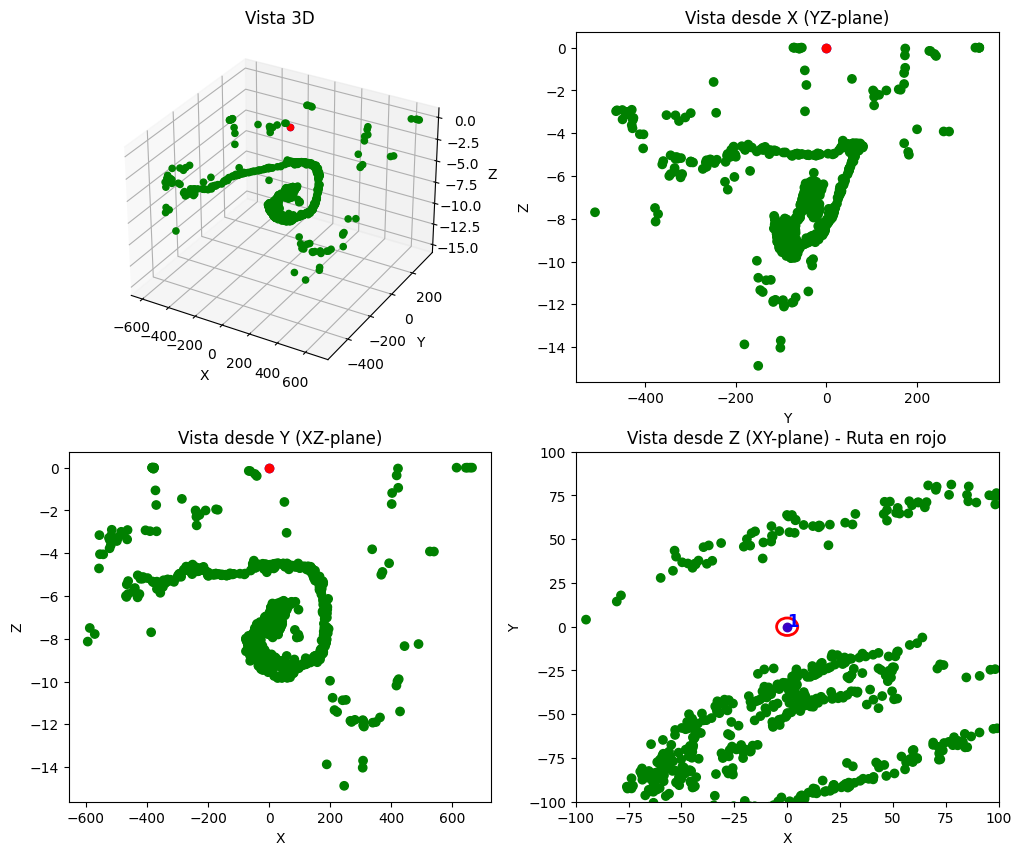

1
Distancia recorrida en este tramo = 23.187273995539567 en 23.187273995539567 s
indice_tVec = 0
Tiempo de la ruta (s): 263.1872739951359
Tiempo del tramo (s): 143.1872739951359
INDICES DETECTADOS = 10.0


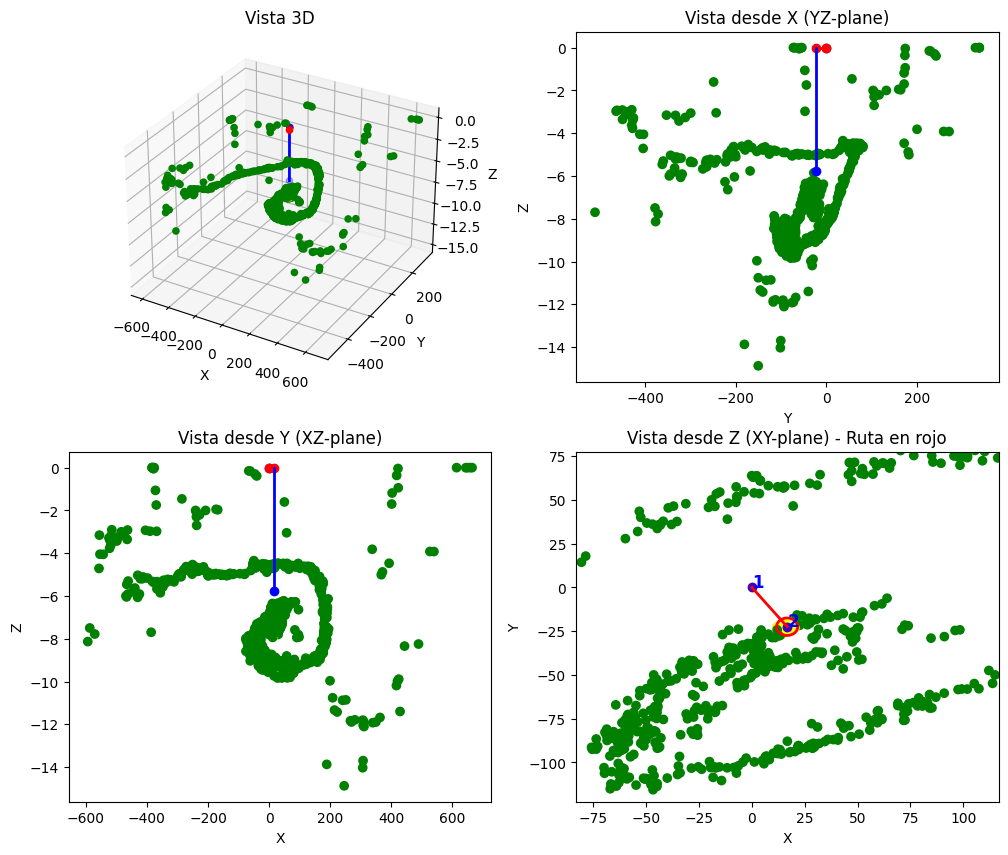

2
Distancia recorrida en este tramo = 5.782056392151662 en 5.782056392151662 s
indice_tVec = 0
Tiempo de la ruta (s): 388.96933038689895
Tiempo del tramo (s): 125.78205639176304
INDICES DETECTADOS = 17.0


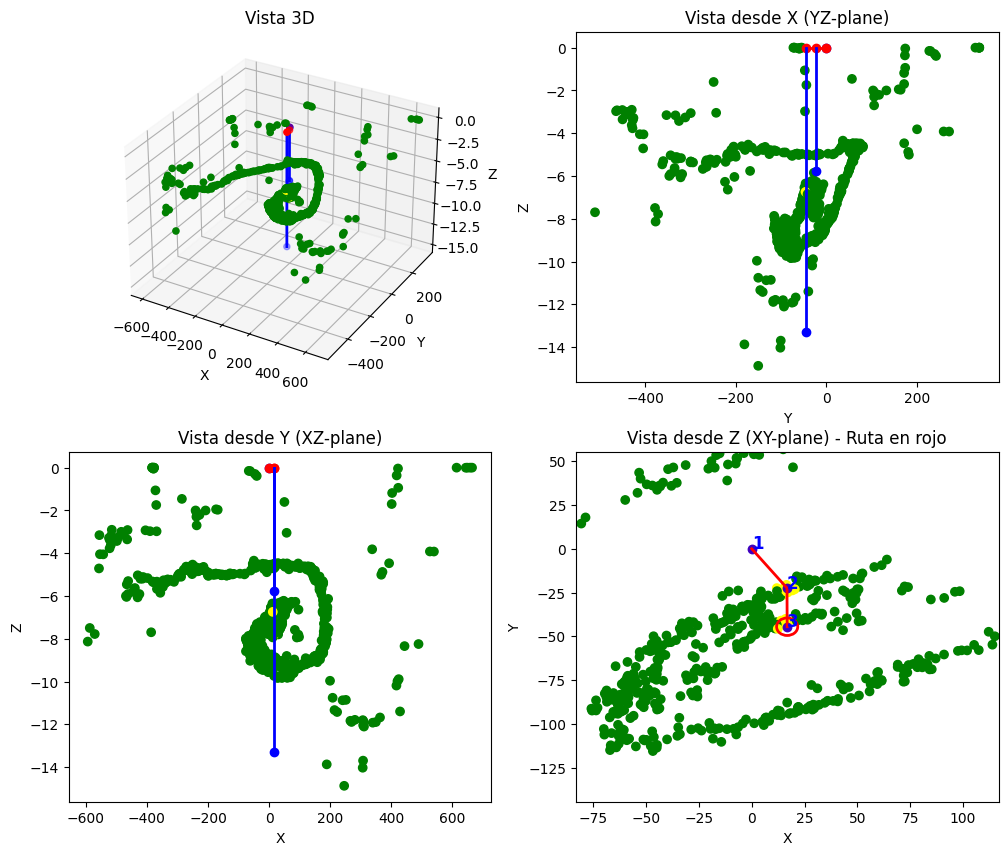

3
Distancia recorrida en este tramo = 22.096473286393746 en 22.096473286393746 s
indice_tVec = 0
Tiempo de la ruta (s): 531.0658036731184
Tiempo del tramo (s): 142.0964732862194
INDICES DETECTADOS = 36.0


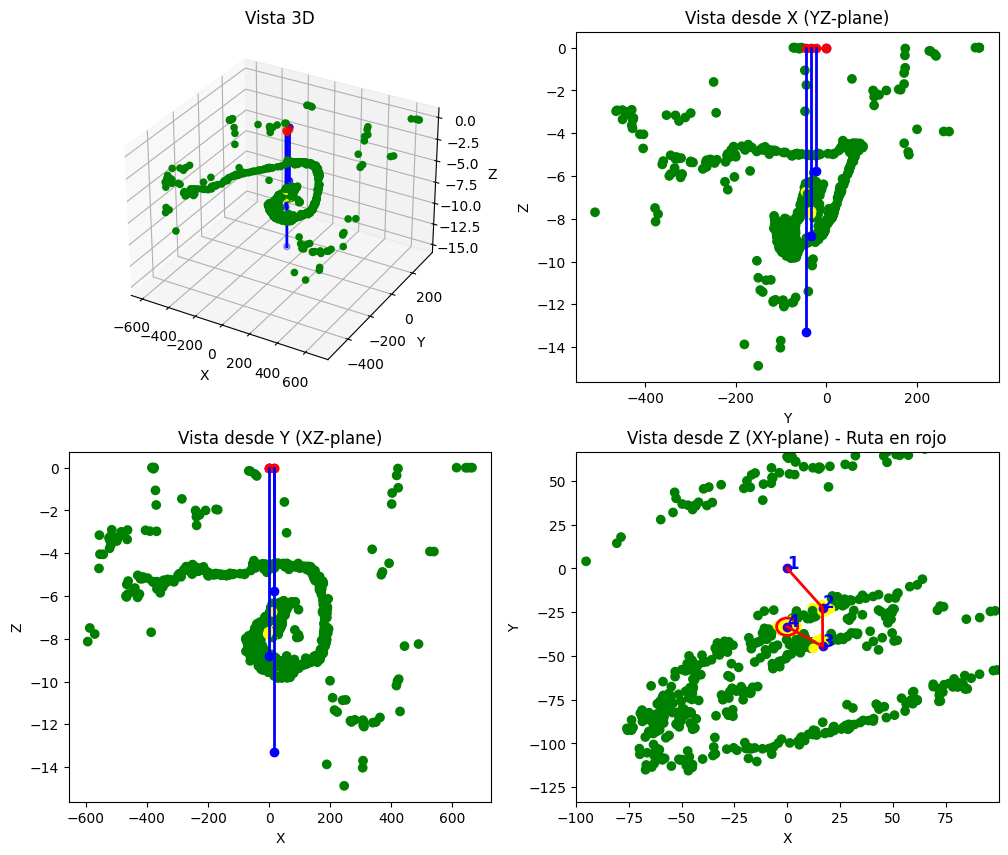

4
Distancia recorrida en este tramo = 23.343603014098335 en 23.343603014098335 s
indice_tVec = 0
Tiempo de la ruta (s): 674.4094066871912
Tiempo del tramo (s): 143.34360301407287
INDICES DETECTADOS = 55.0


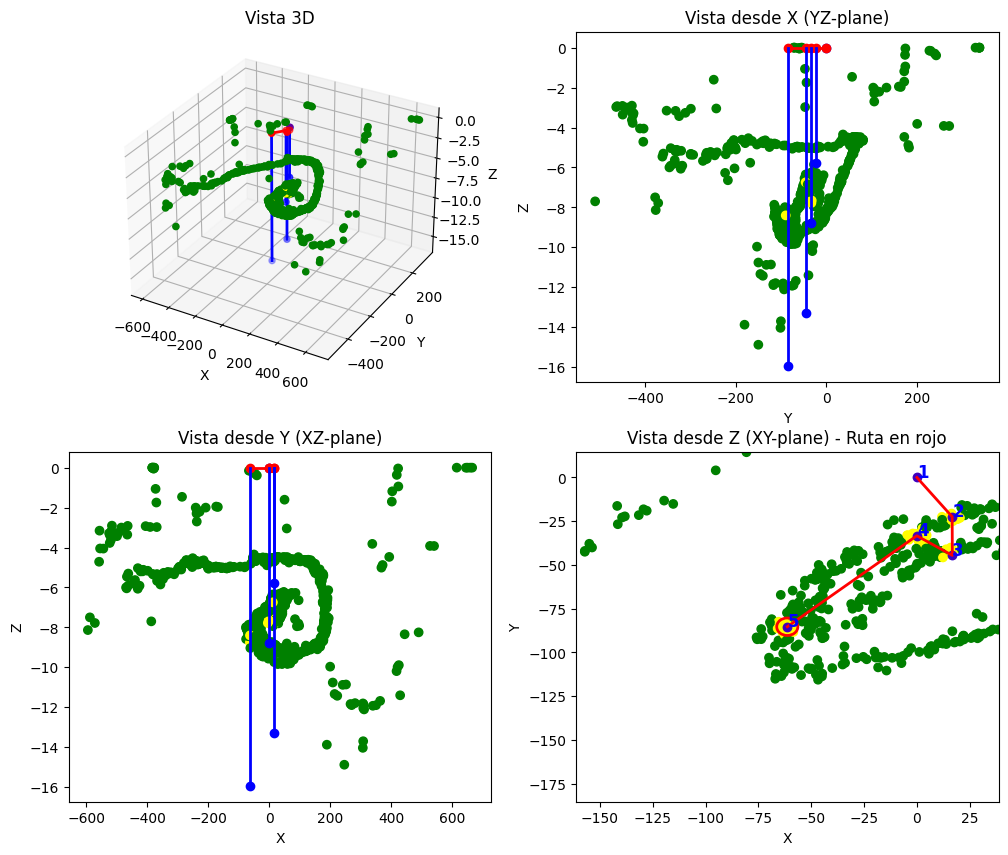

5
Distancia recorrida en este tramo = 18.413649627222686 en 18.413649627222686 s
indice_tVec = 1
Tiempo de la ruta (s): 812.8230563146644
Tiempo del tramo (s): 138.4136496274732
INDICES DETECTADOS = 64.0


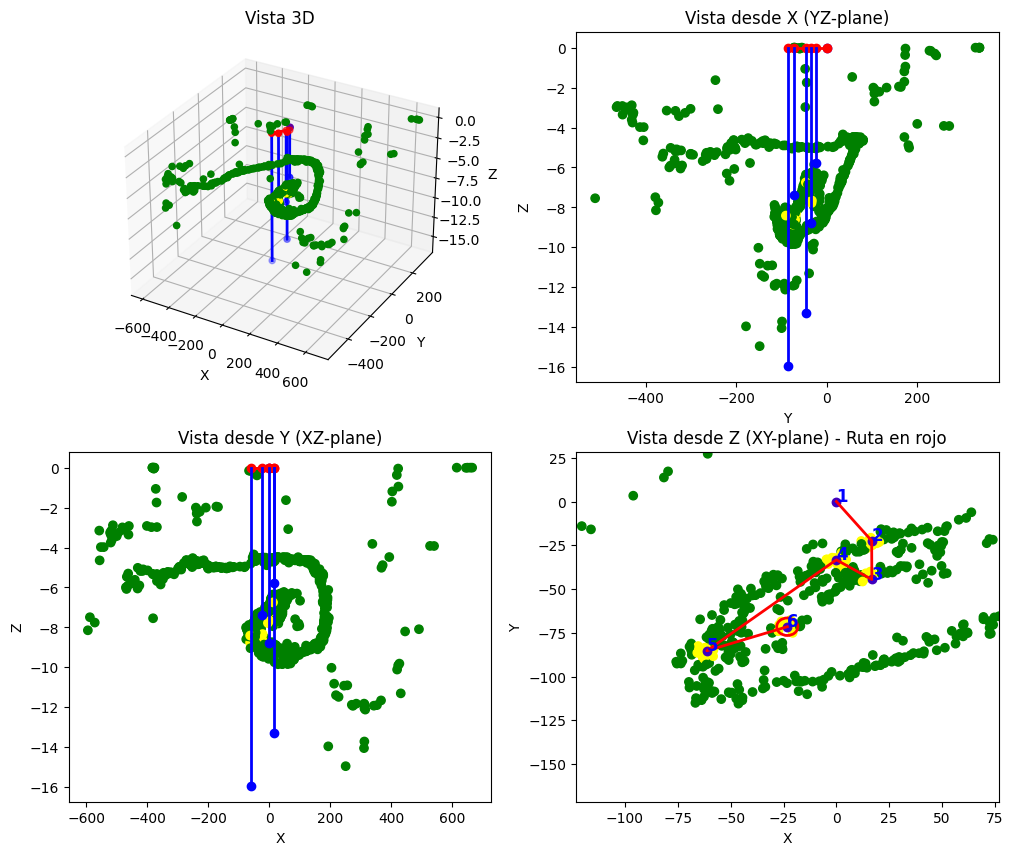

6
Distancia recorrida en este tramo = 20.21335091058245 en 20.21335091058245 s
indice_tVec = 1
Tiempo de la ruta (s): 953.0364072250086
Tiempo del tramo (s): 140.21335091034416
INDICES DETECTADOS = 76.0


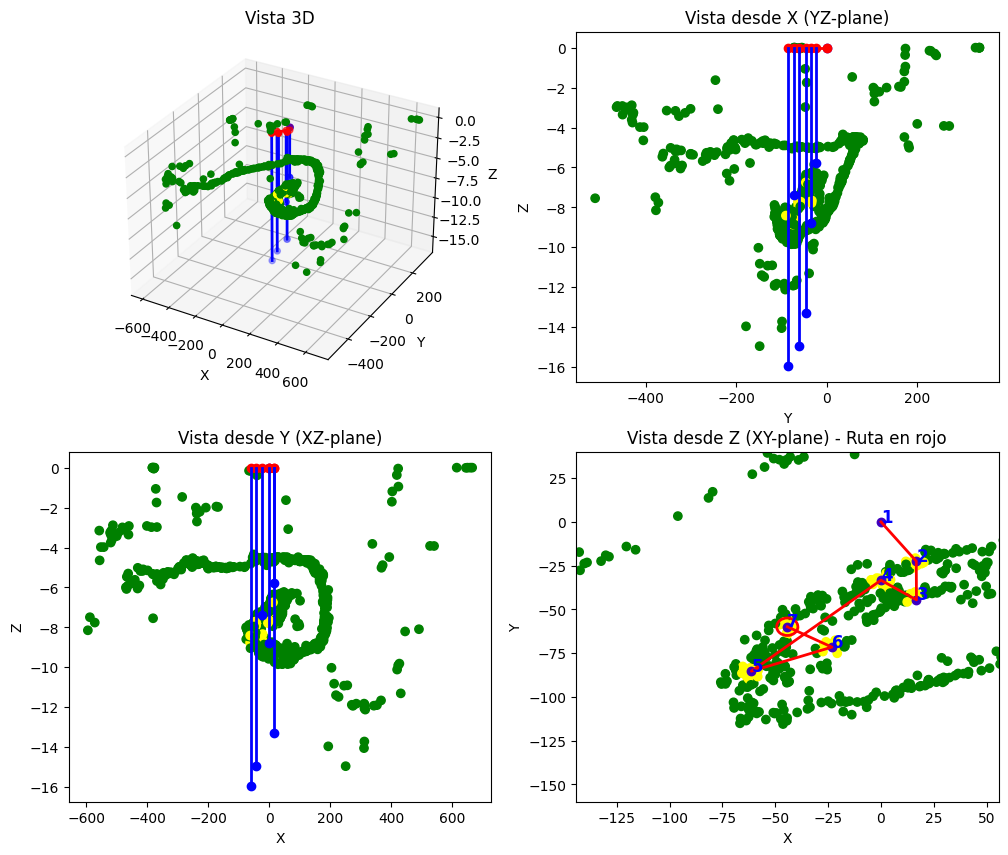

7
Distancia recorrida en este tramo = 12.104238385515368 en 12.104238385515368 s
indice_tVec = 1
Tiempo de la ruta (s): 1085.1406456108089
Tiempo del tramo (s): 132.10423838580027
INDICES DETECTADOS = 84.0


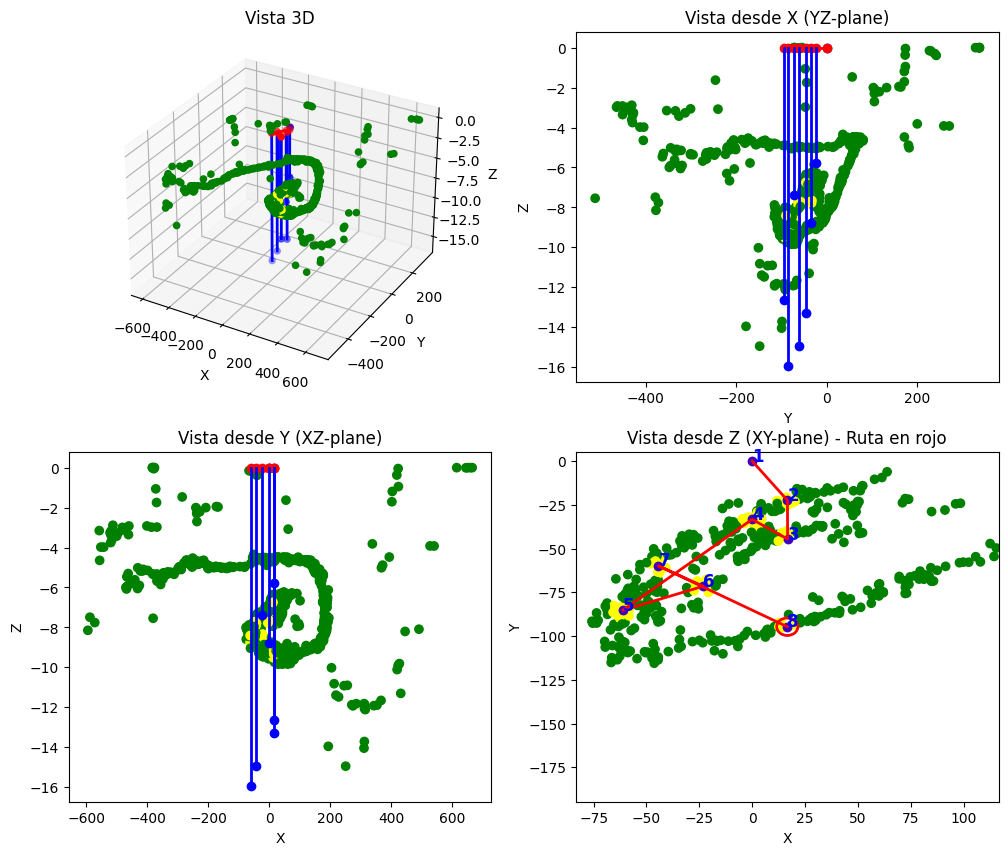

8
Distancia recorrida en este tramo = 61.44957352311928 en 61.449573523119284 s
indice_tVec = 1
Tiempo de la ruta (s): 1266.59021913365
Tiempo del tramo (s): 181.4495735228411
INDICES DETECTADOS = 93.0


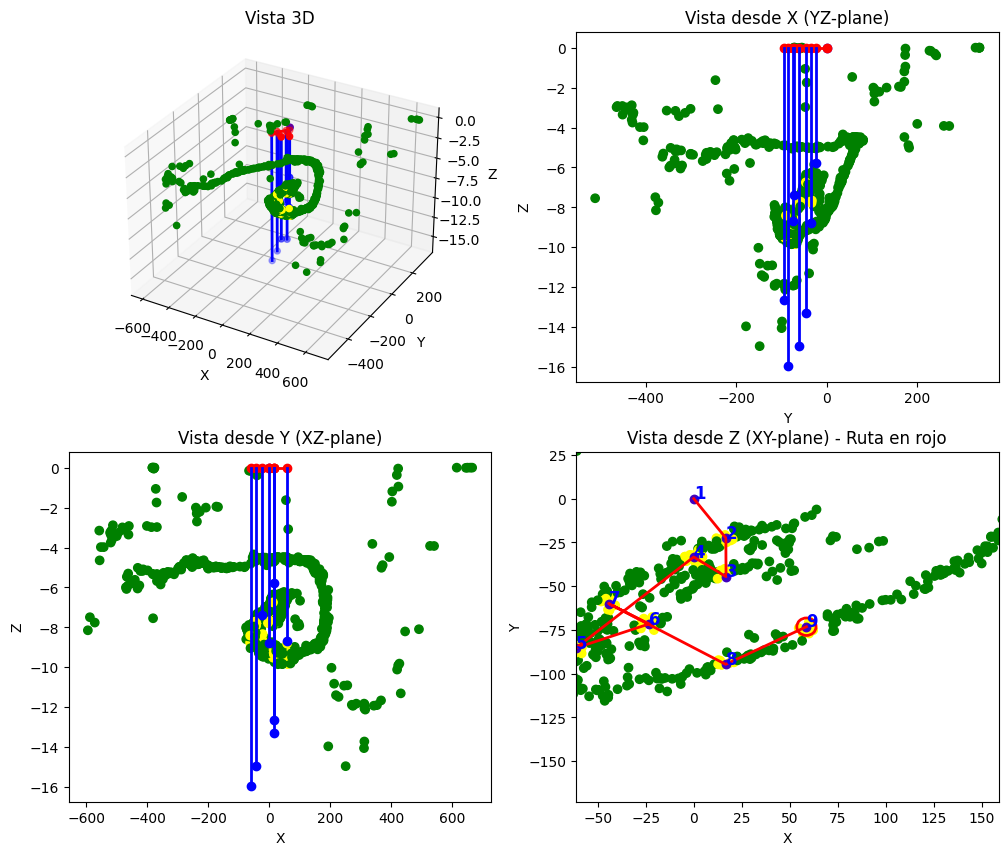

9
Distancia recorrida en este tramo = 80.36351323791241 en 80.36351323791241 s
indice_tVec = 1
Tiempo de la ruta (s): 1466.9537323719123
Tiempo del tramo (s): 200.36351323826239
INDICES DETECTADOS = 93.0


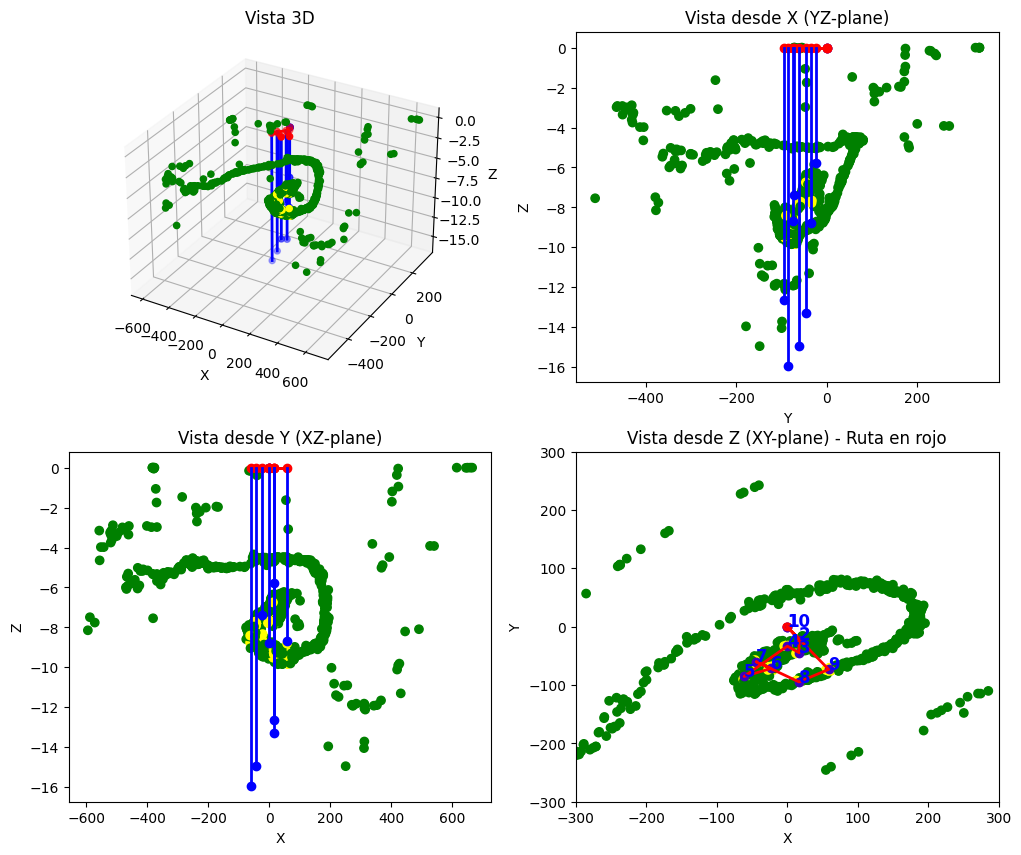

array([93602.        , 93604.38645457, 93606.48282217, 93608.85109673,
       93611.24015678, 93613.54705094, 93615.88394012, 93618.08567743,
       93621.10983699, 93624.44922887])

In [47]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    print(i)
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0] + t_medida
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60) + t_medida  # v_media en m/min. Aquí se suma t_medida sin multiplicar ya que se van cogiendo tiempos anteriores
        print(f"Distancia recorrida en este tramo = {calcular_distancia(p1, p2)} en {(calcular_distancia(p1, p2) / (v_media * 60))*60} s")
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"indice_tVec = {indice_tVec}")
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tVec_min[0, 0])*60}")
    print(f"Tiempo del tramo (s): {(tiempos_ruta[i]-tiempos_ruta[i-1])*60}")
    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]

    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 5  # Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx+1), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    if(i < len(tiempos_ruta)-1 ):
        ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
        ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    else:
        ax4.set_xlim(min(x[0] - 300, min(x)), max(x[0] + 300, max(x)))
        ax4.set_ylim(min(y[0] - 300, min(y)), max(y[0] + 300, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta


MAXIMIZANDO LAS DETECCIONES

In [15]:
best_idx = np.argmin(result.F[:, 1])  # Encuentra el índice del menor valor en la columna 1
mejor_individuo = result.X[best_idx]  # Extrae la solución correspondiente

#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
indices_eliminadas = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0

for i in range(len(recorrido)):
    deteccion = 0
    p1 = recorrido[i]
    if (i < len(recorrido)-1):
        p2 = recorrido[i + 1]
        longitud_recorrido += calcular_distancia(p1, p2)
    #print(f"p{i} = {p1}")
    tAct = tiempo + longitud_recorrido/(problema.v_media*60)
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    # Actualizar el mapa y contar las partículas detectadas
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, problema.rango_deteccion, indices_detectados, indices_eliminadas)
    mapa_dinamico_detecciones[i] = indices_detectados
    print(f"Indices detectados = {np.sum(indices_detectados)}")
detecciones_totales = np.sum(indices_detectados)
print(f"Detecciones totales = {detecciones_totales}")

Indices detectados = 0.0
Indices detectados = 6.0
Indices detectados = 17.0
Indices detectados = 36.0
Indices detectados = 42.0
Indices detectados = 61.0
Indices detectados = 72.0
Indices detectados = 80.0
Indices detectados = 88.0
Indices detectados = 88.0
Detecciones totales = 88.0


Tiempo de la ruta (s): 0.0
INDICES DETECTADOS = 0.0


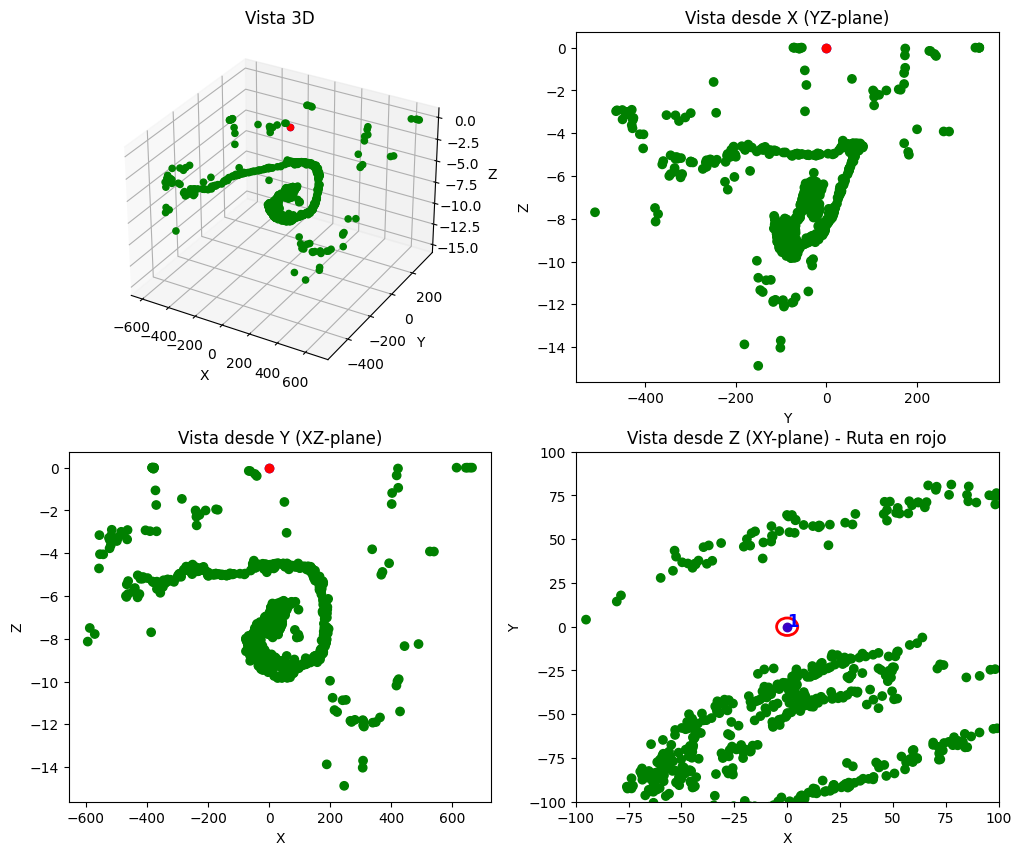

Tiempo de la ruta (s): 38.37777293549152
INDICES DETECTADOS = 6.0


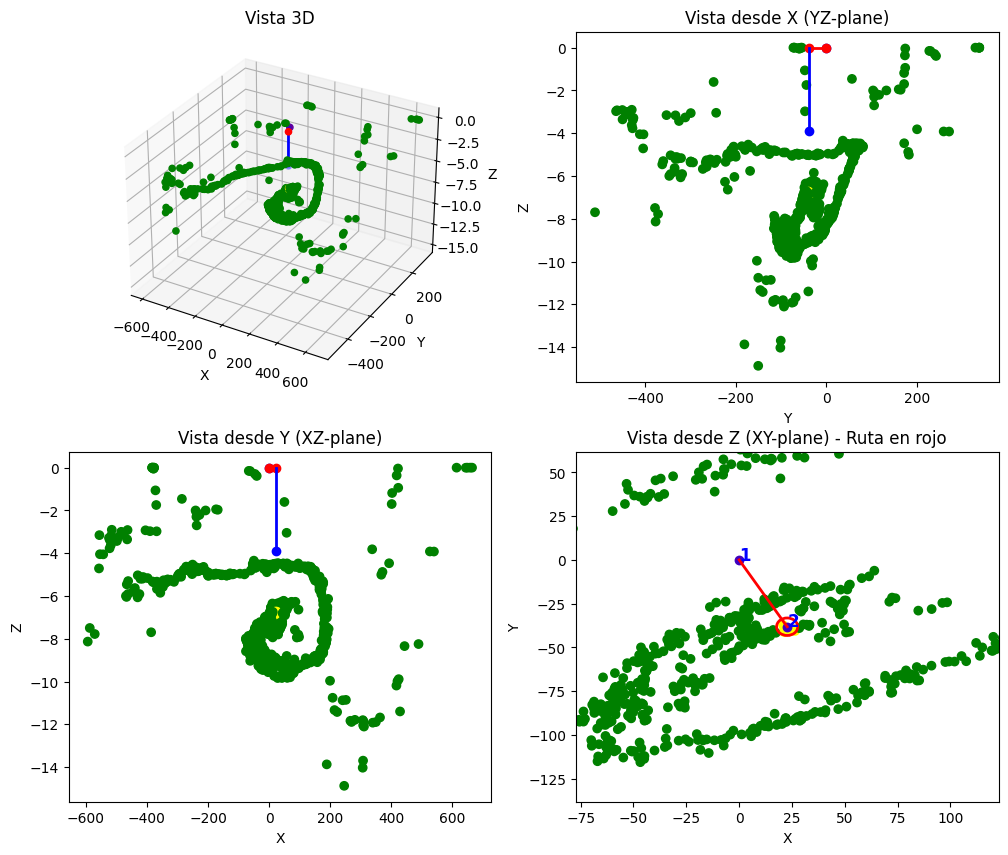

Tiempo de la ruta (s): 43.05041142652044
INDICES DETECTADOS = 17.0


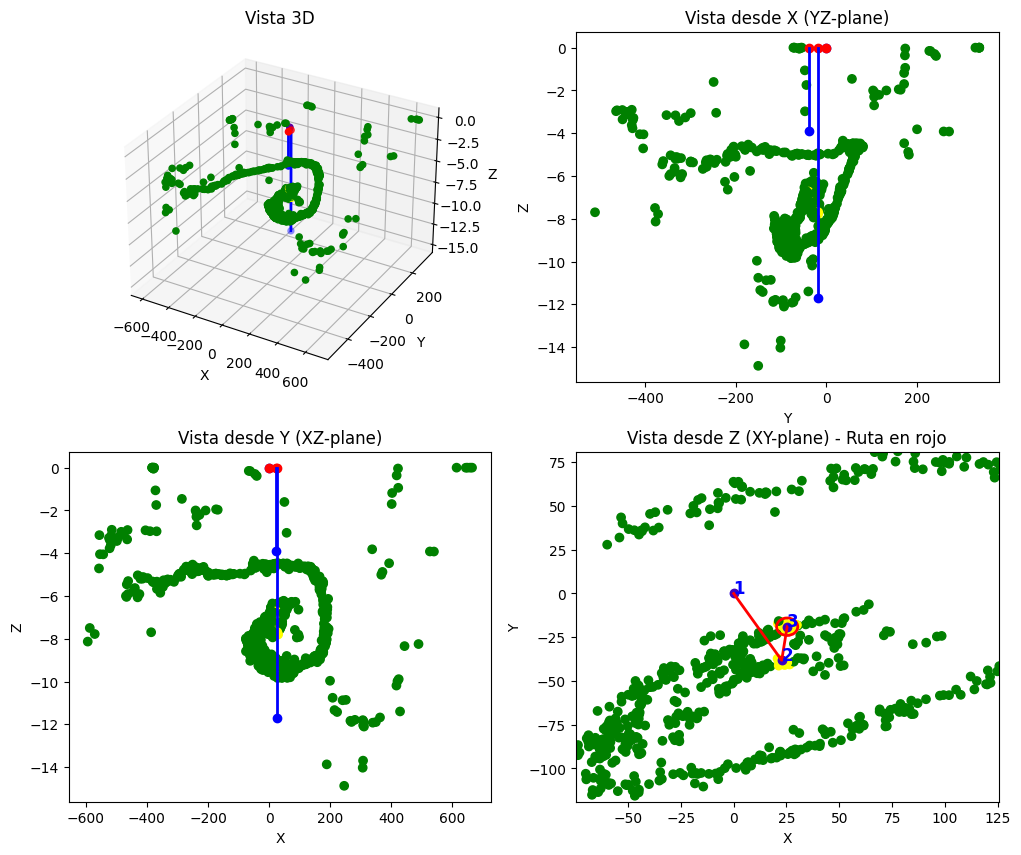

Tiempo de la ruta (s): 62.41556677239714
INDICES DETECTADOS = 36.0


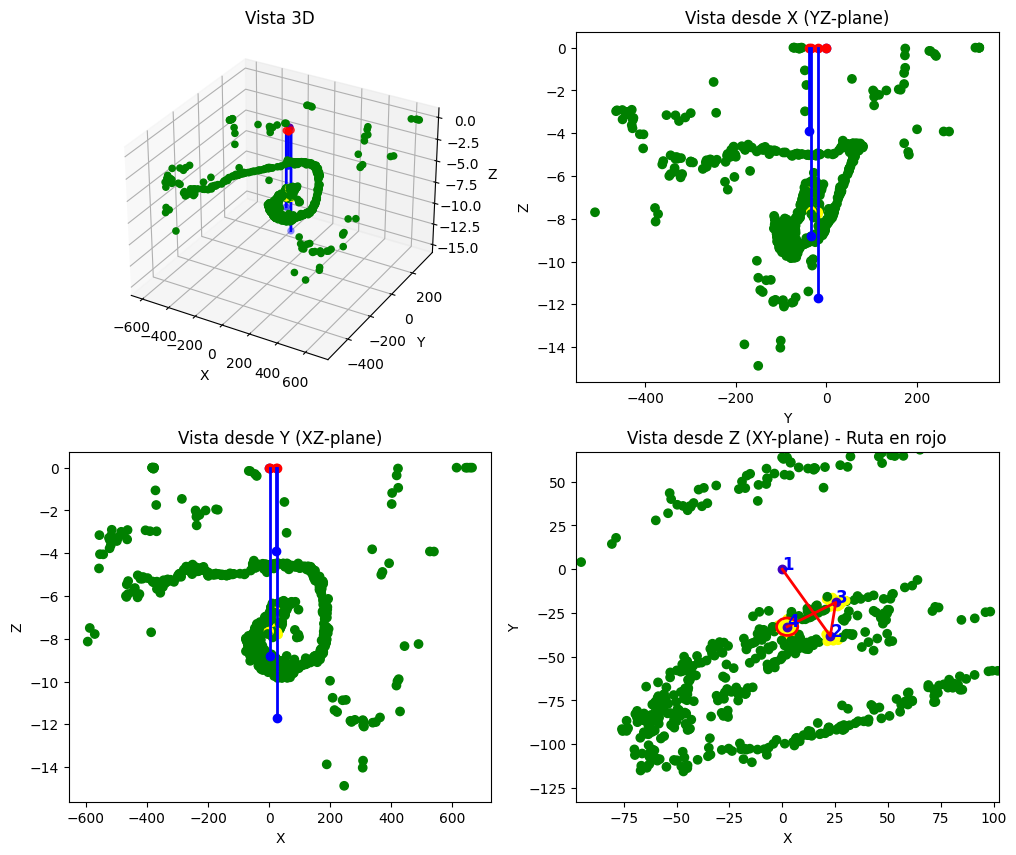

Tiempo de la ruta (s): 83.13342808512971
INDICES DETECTADOS = 42.0


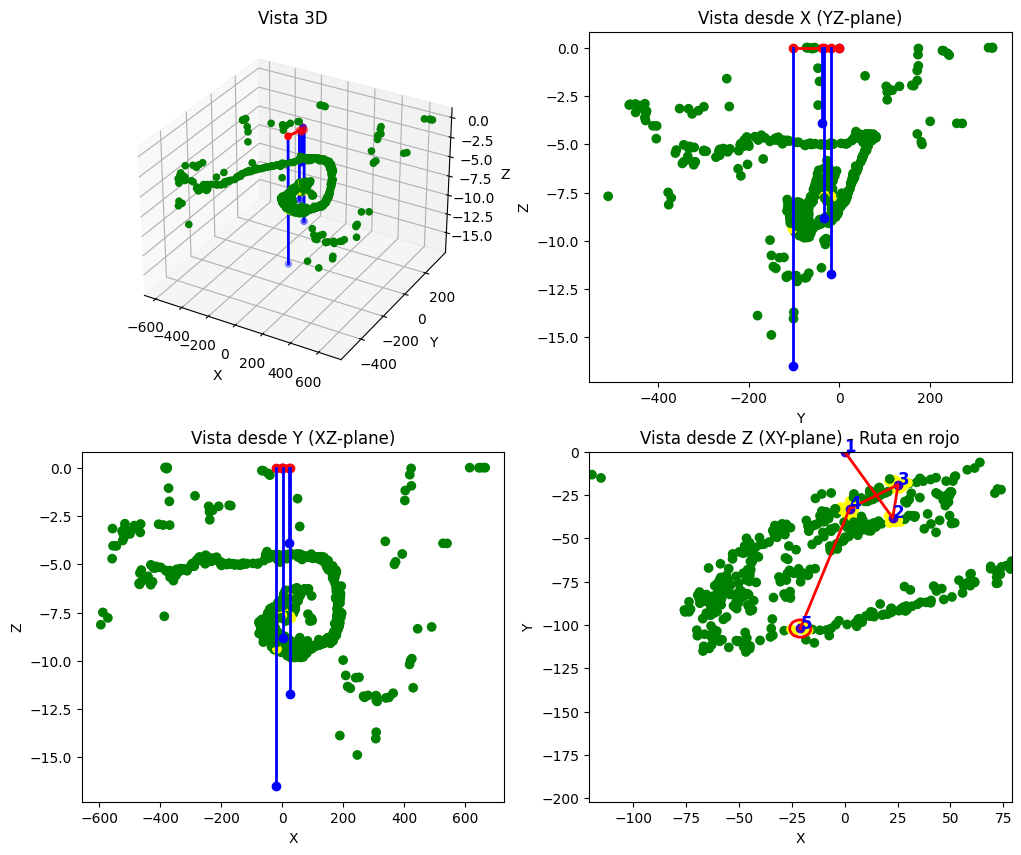

Tiempo de la ruta (s): 107.41985032742377
INDICES DETECTADOS = 61.0


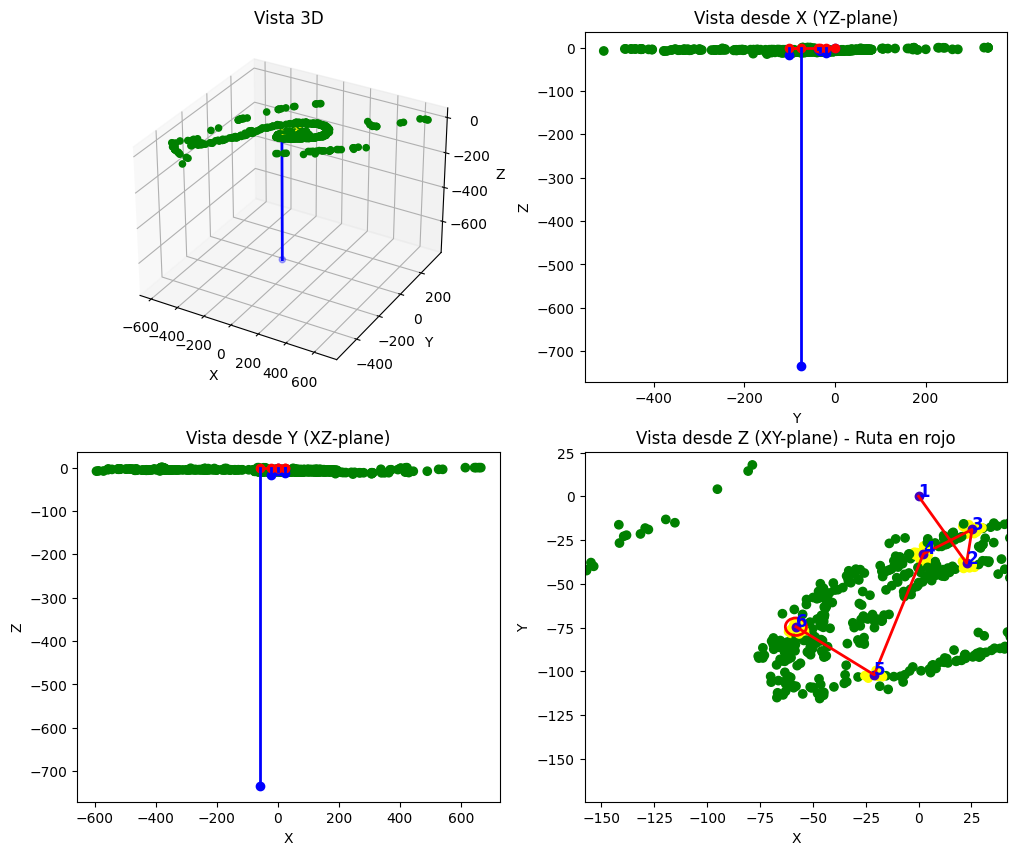

Tiempo de la ruta (s): 134.28798673732672
INDICES DETECTADOS = 72.0


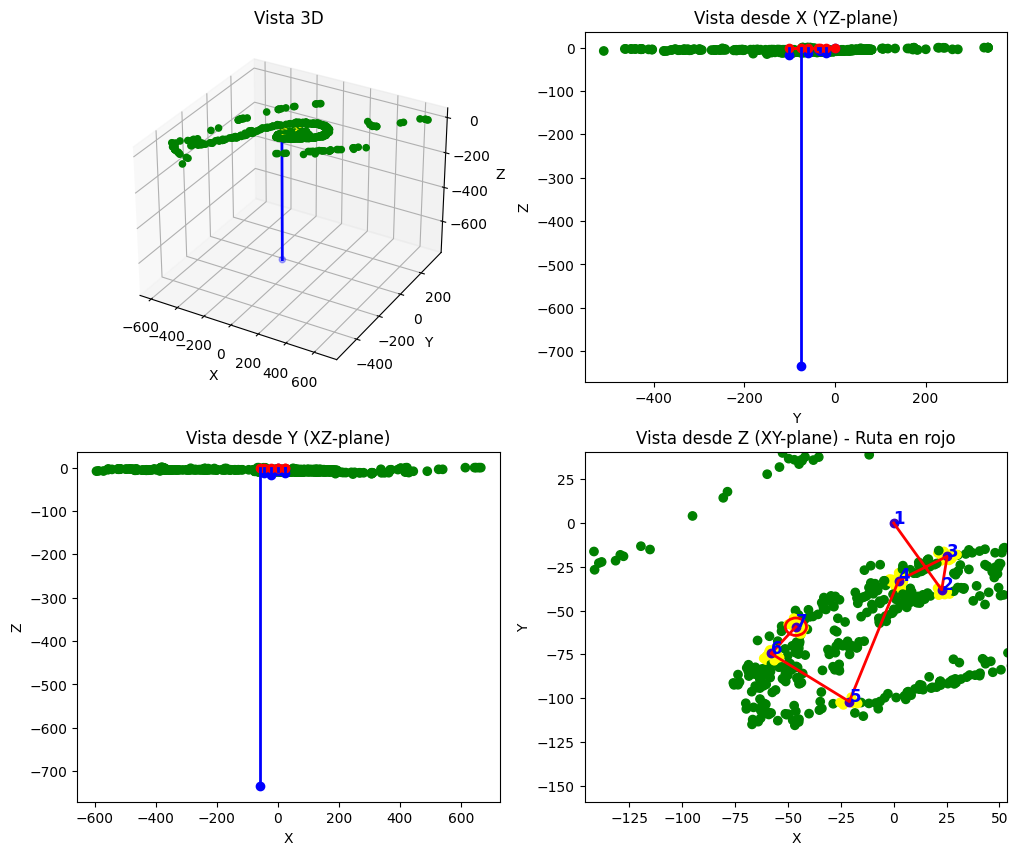

Tiempo de la ruta (s): 148.47879825305426
INDICES DETECTADOS = 80.0


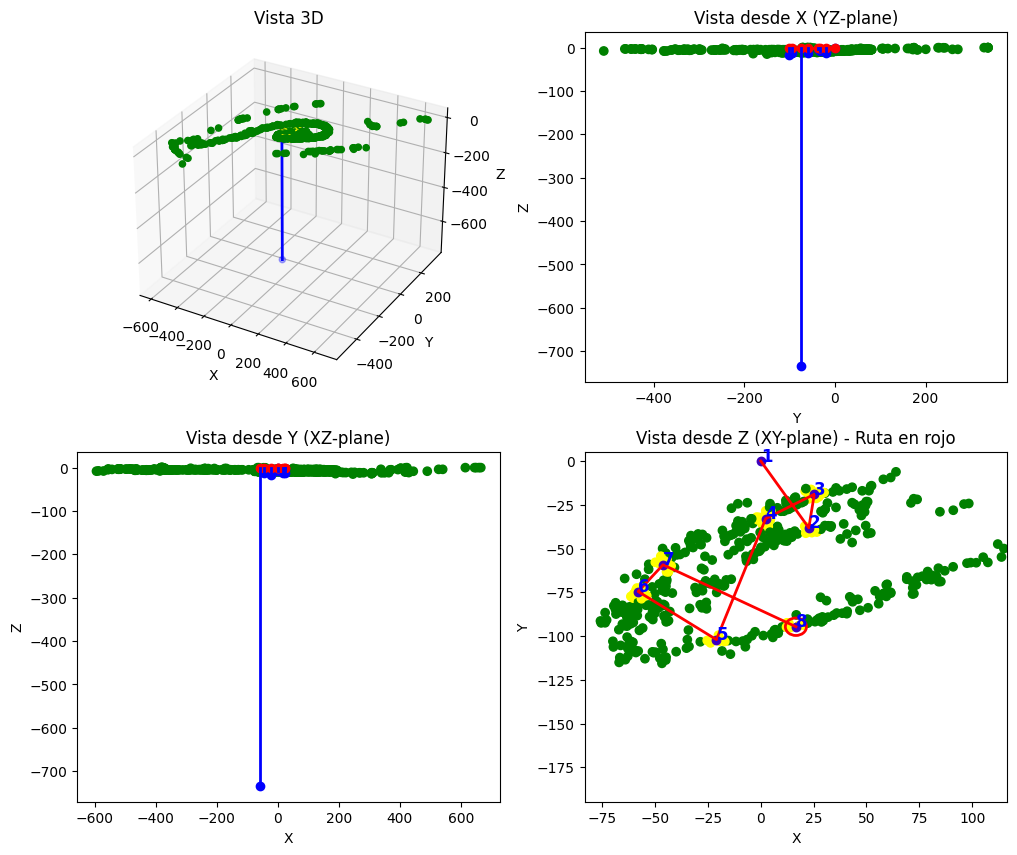

Tiempo de la ruta (s): 171.97878985083662
INDICES DETECTADOS = 88.0


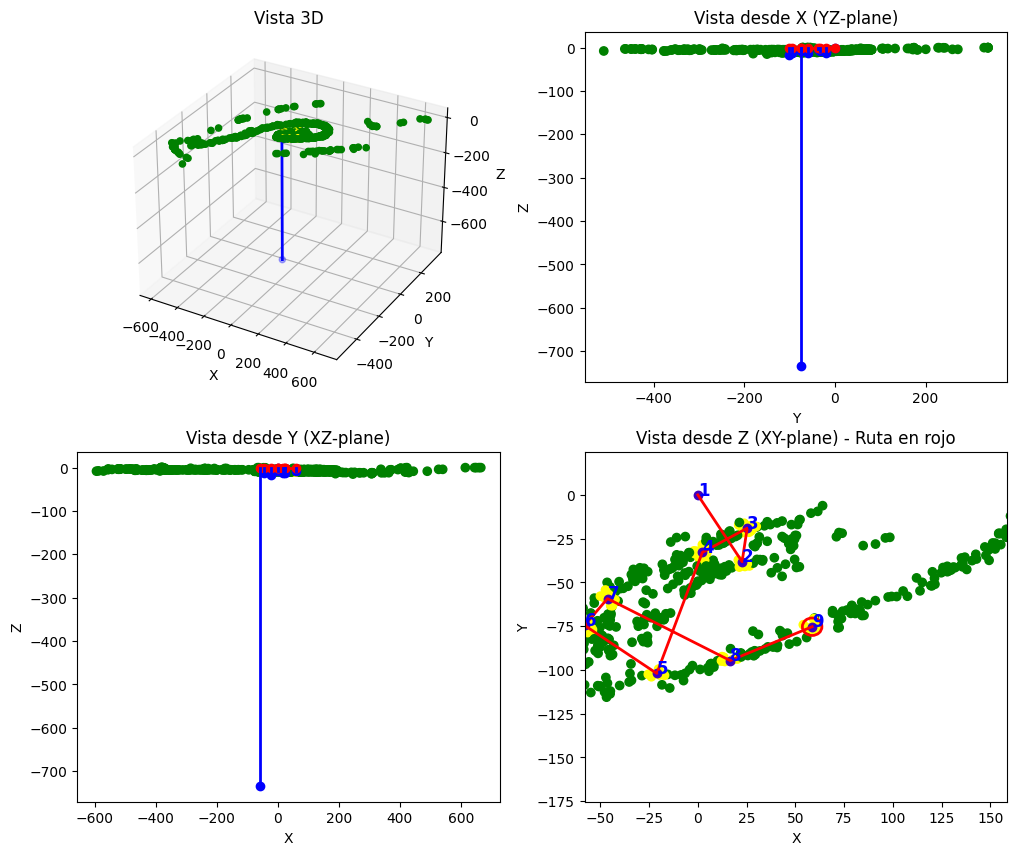

Tiempo de la ruta (s): 244.95253019820666
INDICES DETECTADOS = 88.0


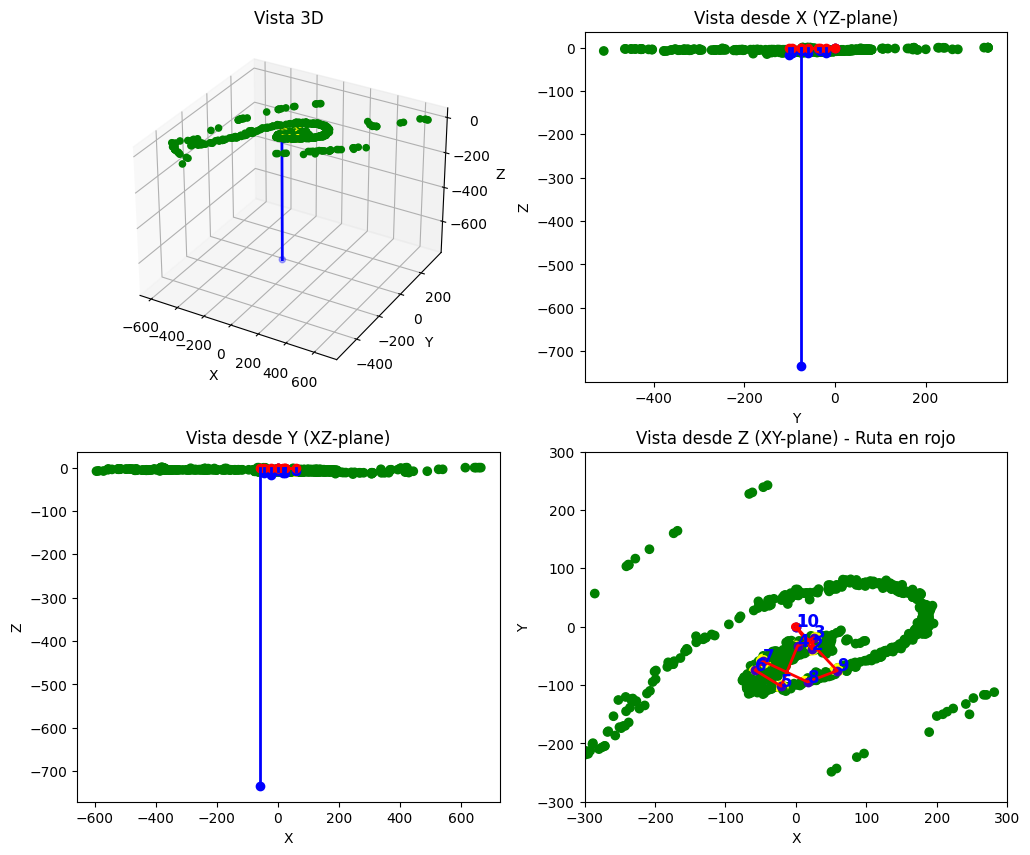

array([93600.        , 93600.63962955, 93600.71750686, 93601.04025945,
       93601.38555713, 93601.79033084, 93602.23813311, 93602.47464664,
       93602.86631316, 93604.08254217])

In [16]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0]
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60)  # v_media en m/min
    
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tiempos_ruta[0])*60}")

    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]

    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 5  # Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx+1), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    if(i < len(tiempos_ruta)-1 ):
        ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
        ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    else:
        ax4.set_xlim(min(x[0] - 300, min(x)), max(x[0] + 300, max(x)))
        ax4.set_ylim(min(y[0] - 300, min(y)), max(y[0] + 300, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta


PUNTO MEDIO DEL FRENTE PARETO

In [65]:
centroid = result.F.mean(axis=0)  # Calcula el centro del frente
distances = np.linalg.norm(result.F - centroid, axis=1)  # Distancia al centroide
best_idx = np.argmin(distances)
mejor_individuo = result.X[best_idx]


#====== Si se quieren poner umbrales ======# 
# filtered_idx = np.where((F[:, 0] <= 0.5) & (F[:, 1] <= 0.3))[0]
# best_idx = filtered_idx[np.argmin(F[filtered_idx, 2])]  # Minimiza el tercer objetivo
# best_solution = pop[best_idx]
#=========================================#

#Ahora saco la evolución de las detecciones al igual que en la evaluacion
# Iterar sobre el recorrido y calcular la longitud total
recorrido = [mejor_individuo[i:i+3] for i in range(0, len(mejor_individuo), 3)]

tiempo=tVec_min[0,0] #Tomamos como orgien el tiempo inicial de la simulación
indices_detectados = np.zeros(len(problema.mapa_particulas[1]))
indices_eliminadas = np.zeros(len(problema.mapa_particulas[1]))
pesos_gaussianos_i =  np.zeros(len(problema.mapa_particulas[1]))
aportaciones = np.zeros(len(problema.mapa_particulas[1]))
indices_repetidas = np.zeros(len(problema.mapa_particulas[1])) 
longitud_recorrido = 0
mapa_dinamico_detecciones = np.zeros((len(recorrido), len(indices_detectados)))
detecciones_totales = 0

for i in range(len(recorrido)):
    deteccion = 0
    p1 = recorrido[i]
    if (i < len(recorrido)-1):
        p2 = recorrido[i + 1]
        longitud_recorrido += calcular_distancia(p1, p2)
    #print(f"p{i} = {p1}")
    tAct = tiempo + longitud_recorrido/(problema.v_media*60)
    dif_tVec_tAct = np.abs(tVec_min - tAct) #Hacemos el absoluto para buscar el 0, es decir, el más cercano al instante actual
    indice_tVec = np.argmin(dif_tVec_tAct) #El índice que tengo que buscar en 
    #print(f"tAct: {tAct}, tVec: {tVec_min}")
    #print(f"Diferencia absoluta: {dif_tVec_tAct}")
    #print(f"Índice del valor más cercano: {indice_tVec}")
    # Actualizar el mapa y contar las partículas detectadas
    indices_detectados, indices_eliminadas = eliminar_particulas_en_rango(xCellLog[indice_tVec, :, :], p1, problema.rango_deteccion, indices_detectados, indices_eliminadas)
    mapa_dinamico_detecciones[i] = indices_detectados
    print(f"Indices detectados = {np.sum(indices_detectados)}")
detecciones_totales = np.sum(indices_detectados)
print(f"Detecciones totales = {detecciones_totales}")

Indices detectados = 0.0
Indices detectados = 11.0
Indices detectados = 29.0
Indices detectados = 29.0
Indices detectados = 49.0
Indices detectados = 58.0
Indices detectados = 65.0
Indices detectados = 65.0
Indices detectados = 72.0
Indices detectados = 72.0
Detecciones totales = 72.0


Tiempo de la ruta (s): 0.0
INDICES DETECTADOS = 0.0


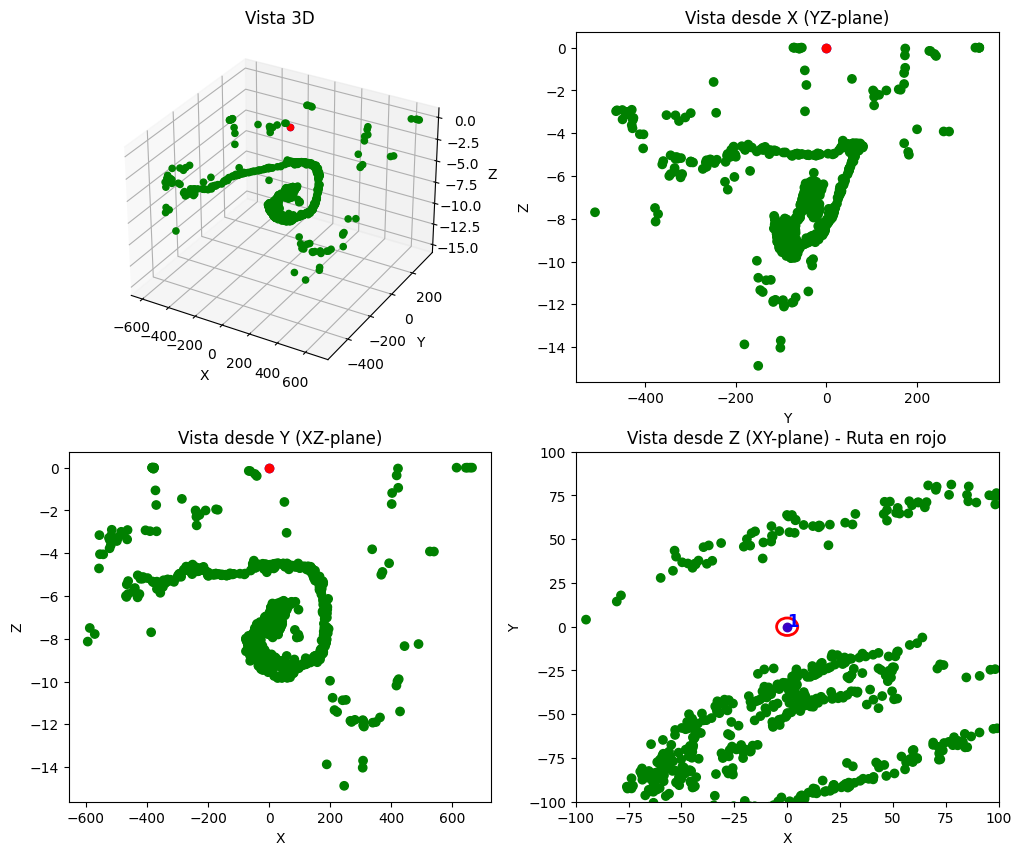

Tiempo de la ruta (s): 25.136292015085928
INDICES DETECTADOS = 12.0


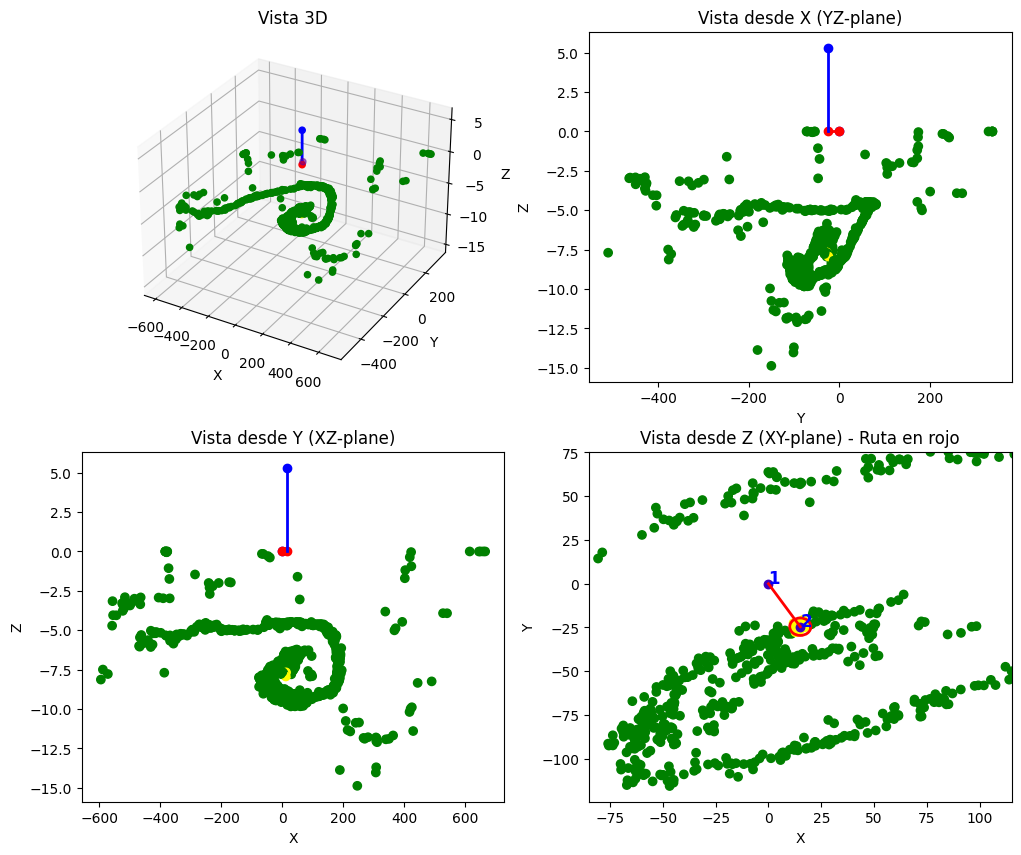

Tiempo de la ruta (s): 32.934890906035434
INDICES DETECTADOS = 32.0


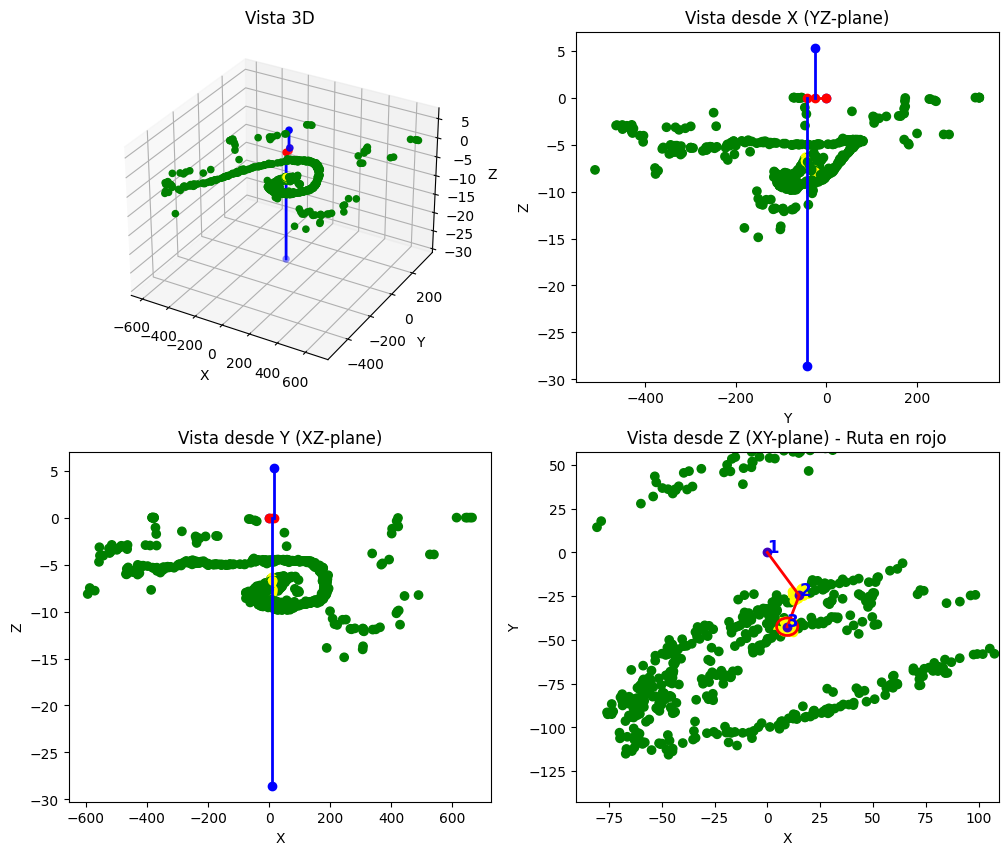

Tiempo de la ruta (s): 51.69936656107893
INDICES DETECTADOS = 43.0


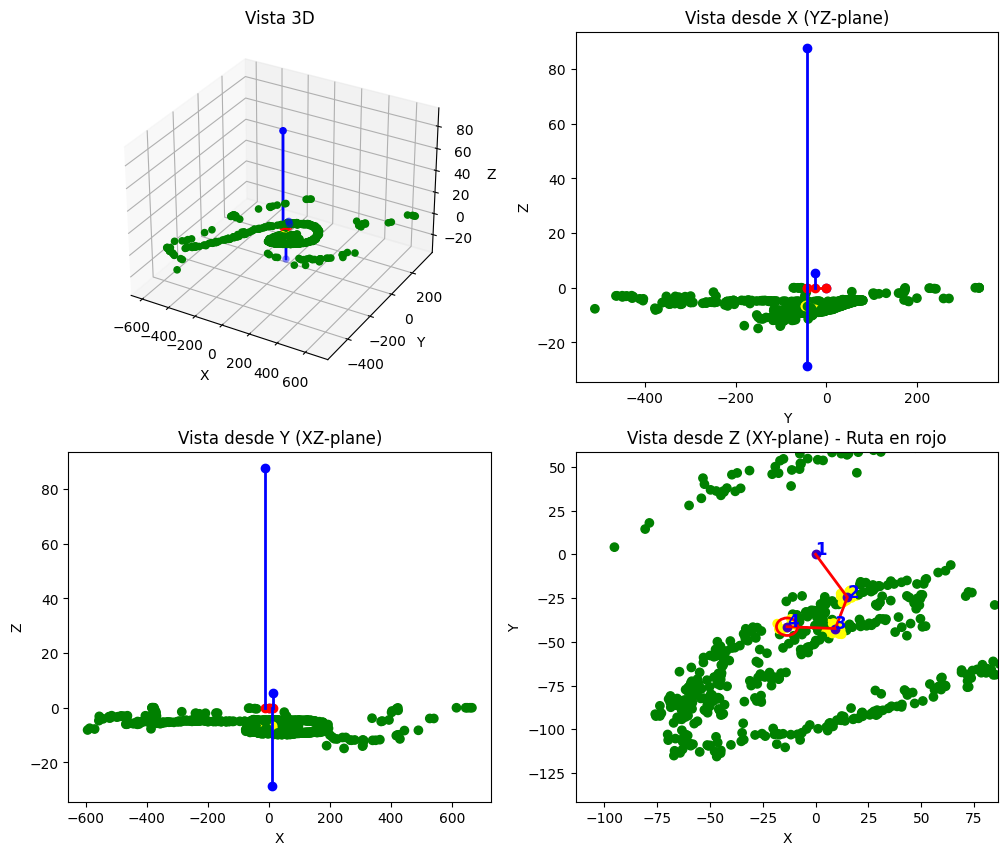

Tiempo de la ruta (s): 89.99776295910124
INDICES DETECTADOS = 62.0


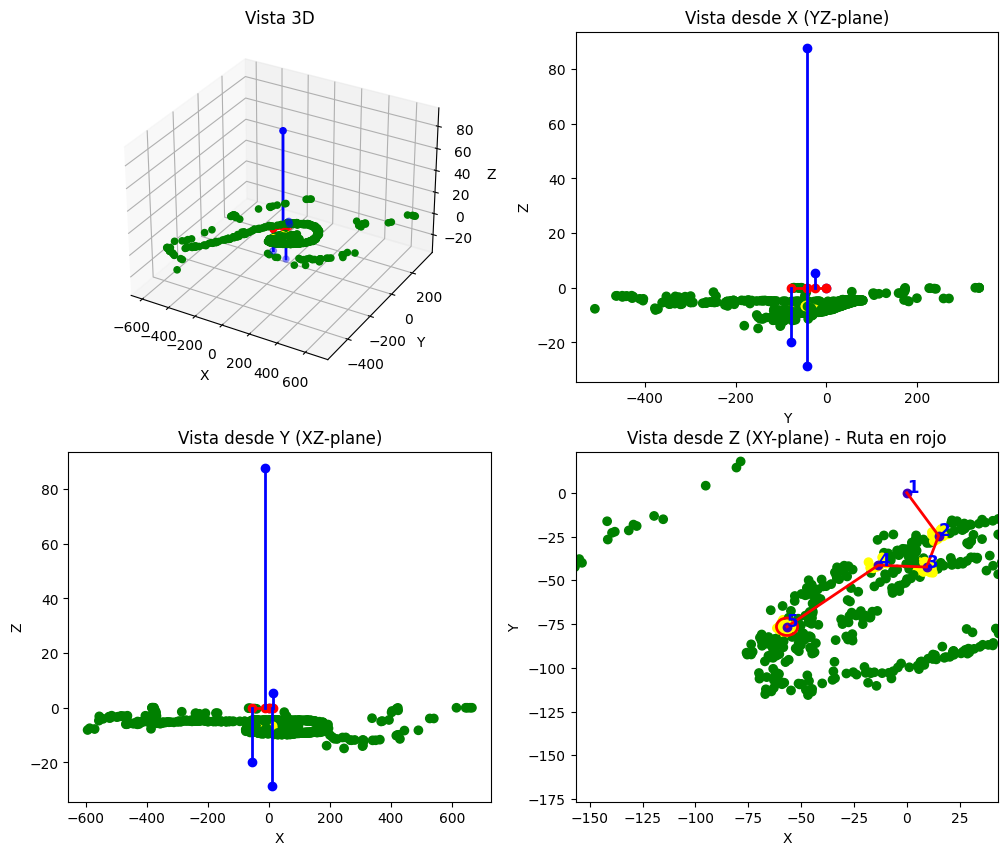

Tiempo de la ruta (s): 130.85384813864948
INDICES DETECTADOS = 62.0


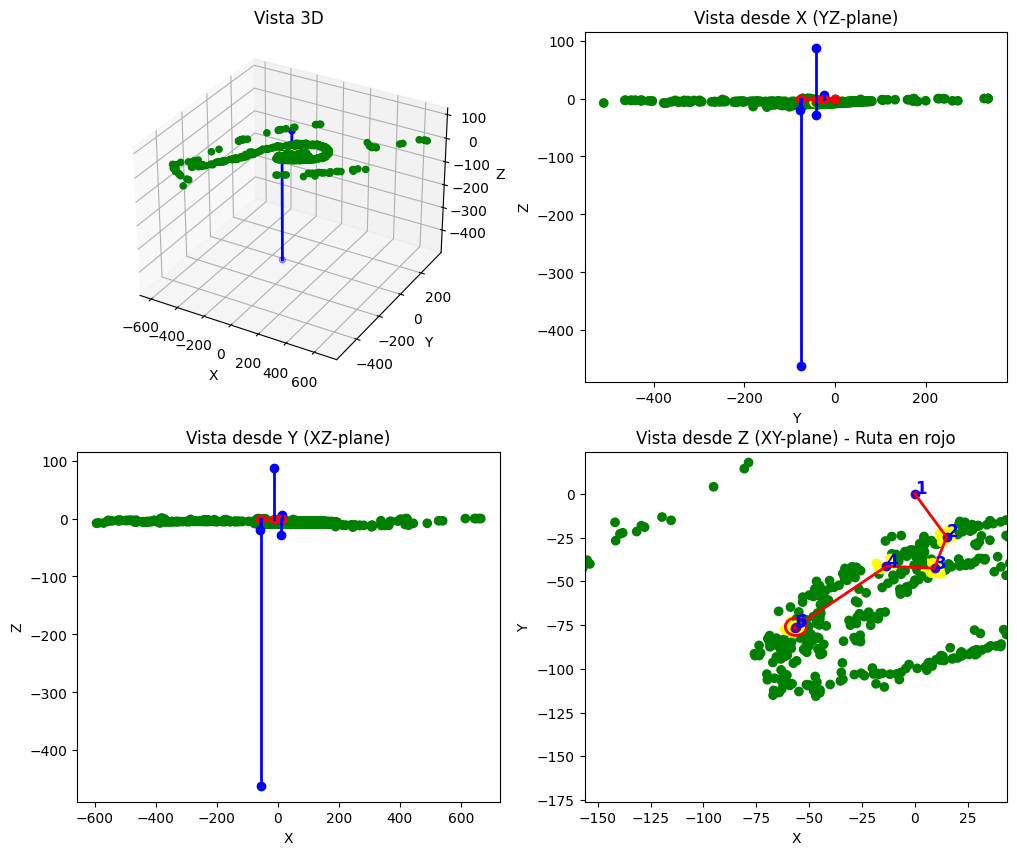

Tiempo de la ruta (s): 153.7251881242264
INDICES DETECTADOS = 73.0


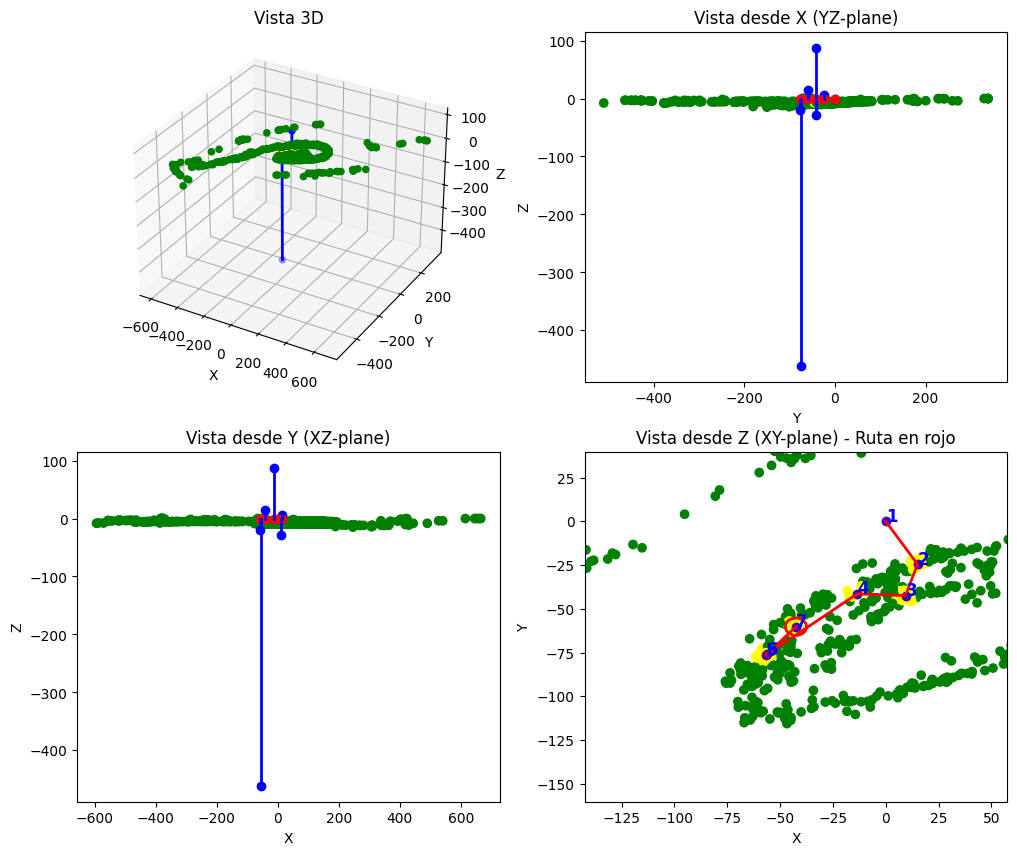

Tiempo de la ruta (s): 270.1079459270113
INDICES DETECTADOS = 89.0


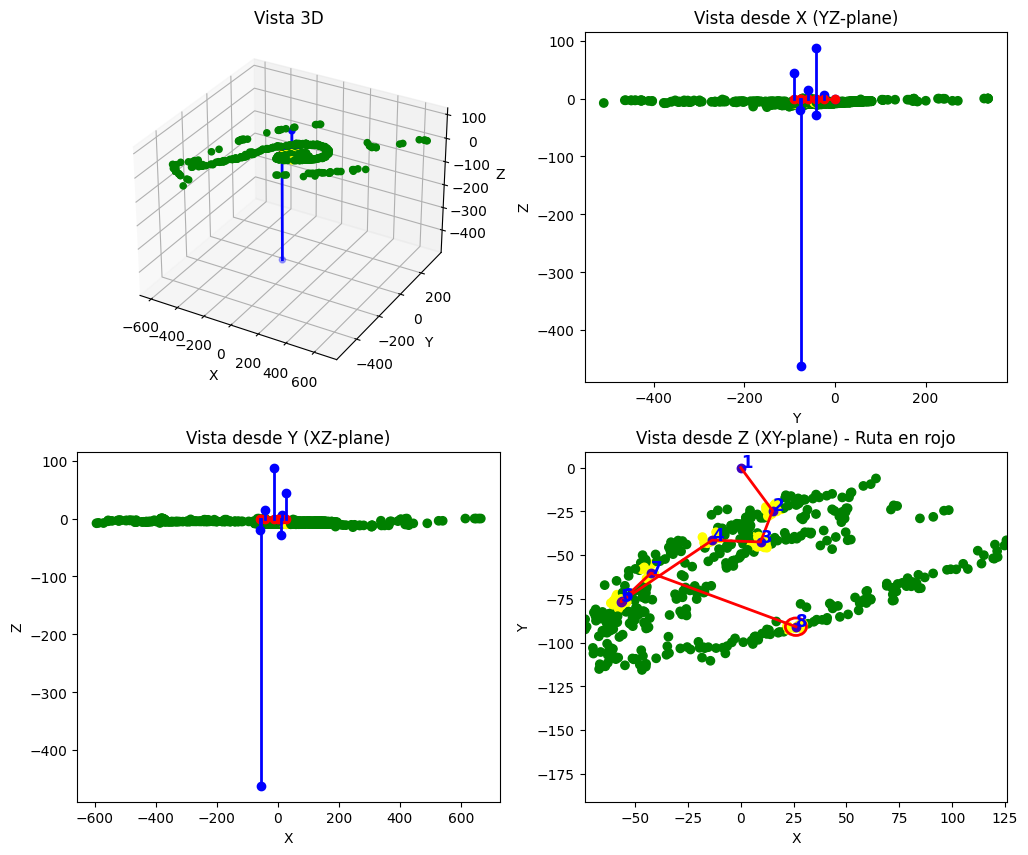

Tiempo de la ruta (s): 394.24222332338104
INDICES DETECTADOS = 91.0


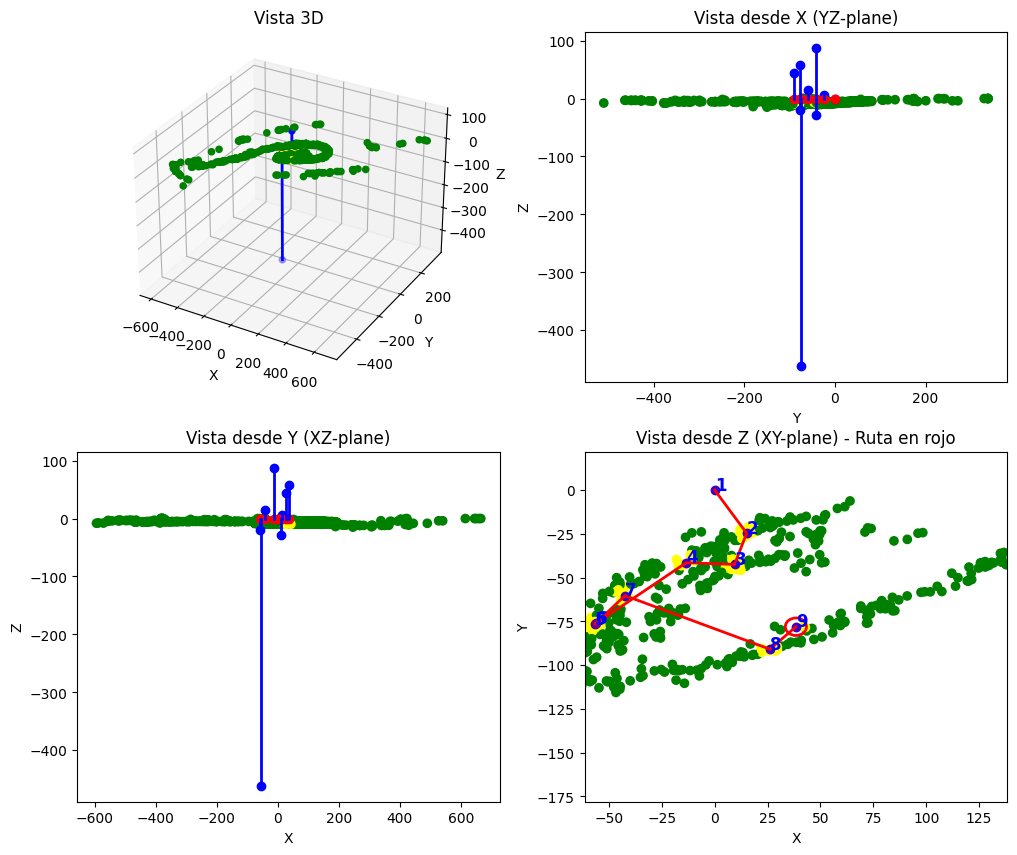

Tiempo de la ruta (s): 449.9189151878818
INDICES DETECTADOS = 91.0


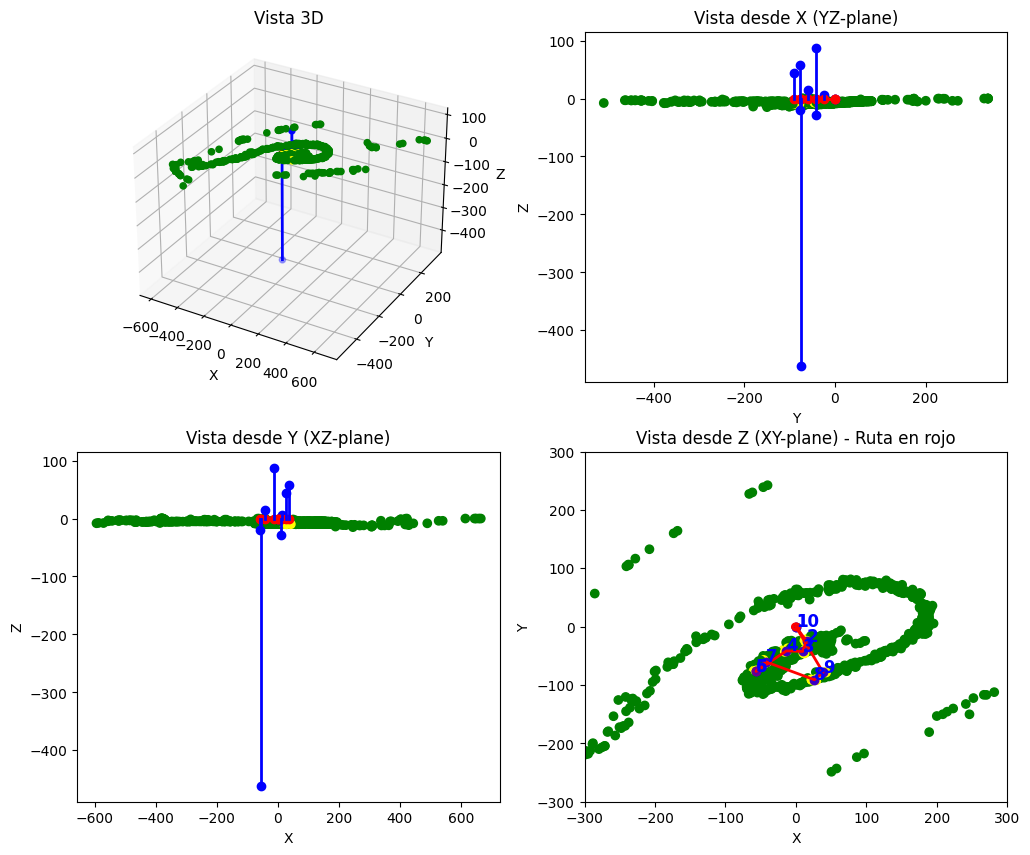

array([93600.        , 93600.4189382 , 93600.54891485, 93600.86165611,
       93601.49996272, 93602.18089747, 93602.56208647, 93604.5017991 ,
       93606.57070372, 93607.49864859])

In [58]:
import numpy as np
import matplotlib.pyplot as plt

mapa_mejor = mapa_dinamico_detecciones

tiempos_ruta = np.zeros(int(len(mejor_individuo) / 3))
x = []
y = []
z = []
j = 0
v_media = 1

plt.ion()  # Activar modo interactivo
zeros = []

for i in range(len(tiempos_ruta)):
    p1 = [mejor_individuo[i], mejor_individuo[i+1], mejor_individuo[i+2]]
    p2 = [mejor_individuo[i+3], mejor_individuo[i+4], mejor_individuo[i+5]]
    zeros.append(0)
    
    # Cálculo de tiempos de la ruta
    if i == 0:
        tiempos_ruta[i] = tVec_min[0, 0]
    else:
        tiempos_ruta[i] = tiempos_ruta[i - 1] + calcular_distancia(p1, p2) / (v_media * 60)  # v_media en m/min
    
    dif_tVec_tAct = np.abs(tVec_min - tiempos_ruta[i])
    indice_tVec = np.argmin(dif_tVec_tAct)
    print(f"Tiempo de la ruta (s): {(tiempos_ruta[i]-tiempos_ruta[0])*60}")

    # Obtener las coordenadas de las partículas
    map_x = xCellLog[indice_tVec, :, 0]
    map_y = xCellLog[indice_tVec, :, 1]
    map_z = xCellLog[indice_tVec, :, 2]

    indices_detectados_i = mapa_mejor[i]
    colores = ["yellow" if indices_detectados_i[k] == 1 else 'green' for k in range(len(indices_detectados_i))]
    print(f"INDICES DETECTADOS = {np.sum(indices_detectados_i)}")
    # Agregar el punto actual antes de graficar
    x.append(mejor_individuo[j])
    y.append(mejor_individuo[j+1])
    z.append(mejor_individuo[j+2])

    # Crear figura con 4 subgráficos
    fig = plt.figure(figsize=(12, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.scatter(map_x, map_y, map_z, c=colores, marker='o', alpha=1)
    ax1.scatter(x, y, z, c='b', marker='o')  # Puntos en 3D
    ax1.scatter(x, y, zeros, c='r', marker='o')  # Puntos proyectados en rojo (Z=0)

    # Líneas rojas entre los puntos proyectados en el suelo (Z=0)
    ax1.plot(x, y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules entre cada punto rojo (proyección) y su correspondiente punto azul en 3D
    for k in range(len(x)):
        ax1.plot([x[k], x[k]], [y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title("Vista 3D")

    # Vista desde X (YZ-plane)
    ax2 = fig.add_subplot(222)
    ax2.scatter(map_y, map_z, c=colores, marker='o', alpha=1)
    ax2.scatter(y, z, c='b', marker='o')
    ax2.scatter(y, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (YZ)
    ax2.plot(y, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(y)):
        ax2.plot([y[k], y[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax2.set_xlabel('Y')
    ax2.set_ylabel('Z')
    ax2.set_title("Vista desde X (YZ-plane)")

    # Vista desde Y (XZ-plane)
    ax3 = fig.add_subplot(223)
    ax3.scatter(map_x, map_z, c=colores, marker='o', alpha=1)
    ax3.scatter(x, z, c='b', marker='o')
    ax3.scatter(x, zeros, c='red', marker='o')

    # Líneas rojas en el suelo (XZ)
    ax3.plot(x, zeros, c='r', linestyle='-', linewidth=2)

    # Líneas azules de proyección de cada punto
    for k in range(len(x)):
        ax3.plot([x[k], x[k]], [0, z[k]], c='b', linestyle='-', linewidth=2)

    ax3.set_xlabel('X')
    ax3.set_ylabel('Z')
    ax3.set_title("Vista desde Y (XZ-plane)")

    # Vista desde Z (XY-plane)
    ax4 = fig.add_subplot(224)
    ax4.scatter(map_x, map_y, c=colores, marker='o', alpha=1)
    ax4.scatter(x, y, c='b', marker='o')
    ax4.scatter(x, y, c='red', marker='o', alpha = 0.2)

    # Línea roja conectando los puntos XY
    ax4.plot(x, y, c='r', linestyle='-', linewidth=2)

    # Dibujar un círculo en el punto actual
    radio = 5# Define el radio del círculo según lo necesites
    circle = plt.Circle((x[-1], y[-1]), radio, color='r', fill=False, linewidth=2)
    ax4.add_patch(circle)  # Agregar el círculo al gráfico
    for idx, (xi, yi, zi) in enumerate(zip(x, y, z)):
        ax4.text(xi, yi, str(idx+1), color='blue', fontsize=12, fontweight='bold')  # Vista XY
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_title("Vista desde Z (XY-plane) - Ruta en rojo")
    if(i < len(tiempos_ruta)-1 ):
        ax4.set_xlim(min(x[-1] - 100, min(x)), max(x[-1] + 100, max(x)))
        ax4.set_ylim(min(y[-1] - 100, min(y)), max(y[-1] + 100, max(y)))
    else:
        ax4.set_xlim(min(x[0] - 300, min(x)), max(x[0] + 300, max(x)))
        ax4.set_ylim(min(y[0] - 300, min(y)), max(y[0] + 300, max(y)))

    # Añadir etiquetas numeradas para cada punto visitado

    plt.show()
    plt.pause(0.1)  # Pequeña pausa para visualizar correctamente
    
    j += 3

tiempos_ruta  # Esta línea muestra los tiempos de la ruta
